### Import Libraries

In [1]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import os
import time
from IPython.display import clear_output
import pathlib
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
import calendar
from scipy.stats import ttest_ind
import matplotlib.patheffects

### Data Scraping

#### Set headers for scraping

In [ ]:
HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
VALID_SEASONS = ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
BASE_URL = 'https://www.transfermarkt.de'

#### Get all teams

In [ ]:
# Get all teams participating in DFB Pokal since 2014-15 season
for season in VALID_SEASONS:
    teams = []
    teams_links = []
    link = BASE_URL + f'dfb-pokal/startseite/pokalwettbewerb/DFB?saison_id={season}'
    response = requests.get(link, headers=HEADERS)
    soup = BeautifulSoup(response.content, 'html.parser')


    # Find all 'tr' tags with the class 'begegnungZeile'
    rows = soup.find_all('tr', class_='begegnungZeile')

    for row in rows:
        home_team = row.find('td', class_='verein-heim')
        away_team = row.find('td', class_='verein-gast')
        if home_team and away_team:
            home_team_title = home_team.find('a')['title']
            home_team_link = home_team.find('a')['href']
            away_team_title = away_team.find_all('a')[1]['title']
            away_team_link = away_team.find_all('a')[1]['href']
            teams_links.append(home_team_link[:-4])
            teams_links.append(away_team_link[:-4])
            teams.append(home_team_title)
            teams.append(away_team_title)

    if len(teams_links) == 0:
        print(f"No teams found for {season} season")
        continue
    else:
        print(f"Found {len(set(teams_links))} teams in {season} season")


    df = pd.DataFrame({'team': teams, 'link': teams_links, 'season': season})

    # Remove duplicates
    df = df.drop_duplicates(subset=['team', 'link'])
    # Reset index
    df = df.reset_index(drop=True)
    # Save to CSV
    df.to_csv(f'datasets/teams/{season}.csv', index=False)

In [13]:
# Path to the folder containing the CSV files
folder_path = 'datasets/teams/'

# List to store dataframes
dataframes = []

# Iterate through all files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        # Read the CSV file and append it to the list
        dataframes.append(pd.read_csv(file_path))

# Combine all dataframes into a single dataframe
combined_df = pd.concat(dataframes, ignore_index=False)

# remove duplicates
combined_df = combined_df.drop_duplicates(subset=['team'])
# Reset index
combined_df = combined_df.reset_index(drop=True)

# Display the combined dataframe
teams_df = combined_df.drop(columns=['season'])

teams_df.to_csv('datasets/teams/teams.csv', index=False)

In [ ]:
# Get additional data for each team

teams_df = pd.read_csv('datasets/teams/teams.csv')
new_data = pd.DataFrame(columns=['link', 'stadium_name', 'total_capacity', 'lawn_heating', 'field_length', 'field_width'])

for index, row in teams_df.iterrows():
    print(f"{index}",end=' ')
    additional_data = {
        'link': '',
        'stadium_name': '',
        'total_capacity': '',
        'lawn_heating': '',
        'field_length': '',
        'field_width': ''
    }

    team_link = row['link']
    final_link = BASE_URL + team_link.replace('spielplan','stadion') + '2014'
    print(final_link)
    response = requests.get(final_link, headers=HEADERS)
    soup = BeautifulSoup(response.content, 'html.parser')
    table = soup.find('table', class_='profilheader')

    # Extract the data from the table
    additional_data['link'] = team_link
    additional_data['stadium_name'] = table.find('th', string='Stadionname:').find_next('td').text.strip()
    try:
        additional_data['total_capacity'] = table.find('th', string='Gesamtkapazität:').find_next('td').text.strip()
    except AttributeError:
        additional_data['total_capacity'] = ''
    try:
        additional_data['lawn_heating'] = table.find('th', string='Rasenheizung:').find_next('td').text.strip()
    except AttributeError:
        additional_data['lawn_heating'] = ''
    
    try:
        playing_surface = table.find('th', string='Spielfeldgröße:').find_next('td').text.strip()
        additional_data['field_length'] = playing_surface.split('x')[0].strip().split('m')[0]
        additional_data['field_width'] = playing_surface.split('x')[1].strip().split('m')[0]
    except AttributeError:
        additional_data['field_length'] = ''
        additional_data['field_width'] = ''

    # Append the data to the new dataframe
    new_data = pd.concat([new_data, pd.DataFrame([additional_data])], ignore_index=True)



In [7]:
# Merge the new data with teams_df on the 'link' column
updated_teams_df = teams_df.merge(new_data, on='link', how='left')

# Display the updated dataframe
updated_teams_df

# Save the updated dataframe to a CSV file
updated_teams_df.to_csv('datasets/teams/teams.csv', index=False)

#### Get all players

In [ ]:
positions = {
    'Torwart': 'GK',
    'Innenverteidiger': 'CB',
    'Abwehr': 'CB',
    'Mittelfeld': 'Midfielder',
    'Linker Verteidiger' : 'LB',
    'Rechter Verteidiger' : 'RB',
    'Defensives Mittelfeld' : 'CDM',
    'Zentrales Mittelfeld' : 'CM',
    'Linkes Mittelfeld' : 'LM',
    'Rechtes Mittelfeld' : 'RM',
    'Offensives Mittelfeld' : 'CAM',
    'Rechtsaußen': 'RW',
    'Linksaußen': 'LW',
    'Mittelstürmer': 'ST',
    'Sturm': 'ST',
    'Hängende Spitze': 'Second Striker',
    'Libero': 'Sweeper',
}

# List of all scraped teams
scraped_teams = [os.path.splitext(f)[0] for f in os.listdir('datasets/players') if f.endswith('.csv')]
scraped_teams.append('SV Drochtersen/Assel')
scraped_teams.append('1.FC Germania Egestorf/Langreder')

teams_df = pd.read_csv('datasets/teams/teams.csv')

for index, row in teams_df.iterrows():
    data = []
    selected_team = row
    if selected_team['team'] in scraped_teams:
        continue
    print(f"Scraping {selected_team['team']}:")
    for season in VALID_SEASONS:
        print(season)
        if season != '2024':
            final_link = BASE_URL + selected_team['link'].replace('spielplan','kader').replace('saison_id/','plus/0/galerie/0?saison_id=') + season
        else: 
            final_link = BASE_URL + selected_team['link'].replace('spielplan','startseite').replace('saison_id/','')
        while True:
                response = requests.get(final_link, headers=HEADERS)
                if response.content and b'Service Unavailable' not in response.content and response.status_code == 200:
                    break
                print("Empty or error response, retrying in 5 seconds...")
                time.sleep(5)
            
        soup = BeautifulSoup(response.content, 'html.parser')
        table = soup.find('table', class_='items')

        # Extract the data from the table
        try:
            rows = table.find_all('tr')[1::3]  # Skip the header row
        except:
            print(f"No data found for {selected_team['team']} in {season} season")
            continue
        for row in rows:
            cols = row.find_all('td')
            if len(cols) > 0:
                try:
                    if season != '2024':
                        player_data = {
                            'name': cols[1].text.strip().split("\n")[0].strip(),
                            'position': positions[cols[1].text.strip().split("\n")[-1].strip()],
                            'age': cols[5].text.strip(),
                            'value': cols[8].text.strip(),
                            'team': selected_team['team'],
                            'season': season,
                        }
                    else:
                        player_data = {
                            'name': cols[1].text.strip().split("\n")[0].strip(),
                            'position': positions[cols[1].text.strip().split("\n")[-1].strip()],
                            'age': cols[5].text.split(' ')[1][1:-1],
                            'value': cols[7].text.strip(),
                            'team': selected_team['team'],
                            'season': season,
                        }
                    data.append(player_data)
                except KeyError:
                    continue

    df = pd.DataFrame(data)

    
    # Remove duplicates
    df = df.drop_duplicates(subset=['name', 'season'])
    # Reset index
    df = df.reset_index(drop=True)
    # Save to CSV
    if '/' in selected_team['team']:
        df.to_csv(f'datasets/players/{selected_team['team'].replace('/','-')}.csv', index=False)
    else:
        df.to_csv(f'datasets/players/{selected_team['team']}.csv', index=False)

    print(f"Saved {selected_team['team']} data to CSV")
    print(f"Sleeping for 1 minutes to avoid overloading the server...")
    time.sleep(60)
    clear_output(wait=True)

In [ ]:
# Path to the folder containing the CSV files
folder_path = 'datasets/players/'

# List to store dataframes
dataframes = []

# Iterate through all files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        # Read the CSV file and append it to the list
        dataframes.append(pd.read_csv(file_path))

# Combine all dataframes into a single dataframe
combined_df = pd.concat(dataframes, ignore_index=False)

# Reset index
combined_df = combined_df.reset_index(drop=True)

combined_df.to_csv('datasets/players/players.csv', index=False)

#### Team Schedules

In [ ]:
# team schedule
teams_df = pd.read_csv('datasets/teams/teams.csv')
scraped_teams = [os.path.splitext(f)[0] for f in os.listdir('datasets/schedules') if f.endswith('.csv')]
for index, row in teams_df.iterrows():
    selected_team = row
    if selected_team['team'] in scraped_teams:
        continue
    print(f"Scraping {selected_team['team']}:")

    data = []
    for season in VALID_SEASONS:
        final_link = BASE_URL + selected_team['link'] + season
        print(season, final_link)


        # Fetch the webpage using requests
        response = requests.get(final_link, headers=HEADERS)

        # Parse the page source with BeautifulSoup
        soup = BeautifulSoup(response.text, 'html.parser')
        if season == '2024':
            competitions = soup.find_all('div', class_='box')[3:-2]
        else:
            competitions = soup.find_all('div', class_='box')[2:-2]
        for competition in competitions:
            # Find the title of the competition
            title = competition.find('a').text.strip()
            table = competition.find('table')
            if table:
                rows = table.find_all('tr')[1:]  # Skip the header row
                for row in rows:
                    cols = row.find_all('td')
                    if len(cols) > 0:
                        try:
                            date = cols[1].text.split('. ')[1].strip()
                            time = cols[2].text.strip()
                        except:
                            date = ''
                            time = ''
                        host = cols[3].text.strip()
                        if host == 'H':
                            home_team = selected_team['team']
                            away_team = cols[6].text.strip().split('(')[0].strip()
                            home_rank = cols[4].text.strip()[1:].split('.')[0]
                            try:
                                away_rank = cols[6].text.strip().split('(')[1].split('.')[0].strip()
                            except:
                                away_rank = ''
                        else:
                            home_team = cols[6].text.strip().split('(')[0].strip()
                            away_team = selected_team['team']
                            try:
                                home_rank = cols[6].text.strip().split('(')[1].split('.')[0].strip()
                            except:
                                home_rank = ''
                            away_rank = cols[4].text.strip()[1:].split('.')[0]
                        
                        participants = cols[8].text.strip()
                        result = cols[9].text.strip()
                        try:
                            home_score = result.split(':')[0].strip()
                            away_score = result.split(':')[1].split(' ')[0].strip()
                        except:
                            home_score = ''
                            away_score = ''

                        match_link = cols[9].find('a')['href']
                        match_data = {
                            'date': date,
                            'time': time,
                            'home_team': home_team,
                            'away_team': away_team,
                            'participants': participants,
                            'home_score': home_score,
                            'away_score': away_score,
                            'match_link': match_link,
                            'season': season,
                            'competition': title,
                        }
                        # Append the data to the list
                        data.append(match_data)
    df = pd.DataFrame(data)
    clear_output(wait=True)

    df.to_csv(f'datasets/schedules/{selected_team['team'].replace('/','-')}.csv', index=False)

In [ ]:
# Path to the folder containing the CSV files
folder_path = 'datasets/schedules/'

# List to store dataframes
dataframes = []

# Iterate through all files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        # Read the CSV file and append it to the list
        dataframes.append(pd.read_csv(file_path))

# Combine all dataframes into a single dataframe
combined_df = pd.concat(dataframes, ignore_index=False)


# Remove duplicates
combined_df = combined_df.drop_duplicates()

# Reset index
combined_df = combined_df.reset_index(drop=True)


combined_df.to_csv('datasets/schedules/schedules.csv', index=False)

In [ ]:
# Get lineups for a specific match

penalty = 5

def get_lineup_link(match_link, penalty=5): 
  while True:
    response = requests.get(match_link, headers=HEADERS)
    if response.content and b'Service Unavailable' not in response.content and response.status_code == 200:
      break
    print("Empty or error response, retrying in 5 seconds...")
    time.sleep(penalty)
    penalty += 10
  soup = BeautifulSoup(response.content, 'html.parser')


  canonical_link = soup.find('link', rel='canonical')

  canonical_href = canonical_link.get('href')
  linup_link = '/' + canonical_href.split('/')[3]
  lineup_final_link = BASE_URL +  linup_link + '/aufstellung/spielbericht/' + selected_match['match_link'].split('/')[-1]
  return lineup_final_link, penalty

matches_df = pd.read_csv('datasets/schedules/schedules.csv')

# get lineups for all matches
lineups_path = 'datasets/lineups/lineups.csv'
lineups_dir = pathlib.Path(lineups_path).parent
lineups_dir.mkdir(parents=True, exist_ok=True)

if os.path.exists(lineups_path):
  lineups_df = pd.read_csv(lineups_path)
else:
  lineups_df = pd.DataFrame(columns=['player_name', 'match_link', 'home_team'])

for index, row in matches_df.iterrows():

  print(f"{index} mathes processed")

  selected_match = row
  match_link = selected_match['match_link']
  if match_link not in lineups_df['match_link'].values:

    final_link = BASE_URL + match_link

    final_link, penalty = get_lineup_link(final_link,penalty)
    while True:
      response = requests.get(final_link, headers=HEADERS)
      if response.content and b'Service Unavailable' not in response.content and response.status_code == 200:
        break
      print("Empty or error response, retrying in 5 seconds...")
      time.sleep(penalty)
      penalty += 10
      
    soup = BeautifulSoup(response.content, 'html.parser')
    tables = soup.find_all('table', class_='items')[:2]

    # Extract the data from the tables
    player_data = []
    home_team = True
    for table in tables:
      for row in table.find_all('tr'):
        tds = row.find_all('td')
        if len(tds) < 3:
          continue

        # Player name and age
        inline_table = tds[1].find('table', class_='inline-table')
        if inline_table:
          name_tag = inline_table.find('a', class_='wichtig')
          player_name = name_tag.text.strip() if name_tag else ''
          
          
        player_data.append({
          'player_name': player_name,
          'match_link': match_link,
          'home_team': home_team
        })
      home_team = not home_team
    
    # Convert the list of dictionaries to a DataFrame
    lineup_df = pd.DataFrame(player_data)

    # Only append new rows (avoid duplicates based on player_name, match_link, home_team)
    if not lineup_df.empty:
      merged_df = pd.concat([lineups_df, lineup_df], ignore_index=True)
      merged_df = merged_df.drop_duplicates(subset=['player_name', 'match_link', 'home_team'])
      merged_df.to_csv(lineups_path, index=False)
      lineups_df = merged_df

    time.sleep(penalty * 2)
    penalty = 5
    clear_output(wait=True)


In [ ]:
player_data = pd.read_csv('datasets/players/players.csv')
shcedules_data = pd.read_csv('datasets/schedules/schedules.csv')

selected_player = player_data.iloc[0]
selected_player
player_team = pd.concat([
    shcedules_data[shcedules_data['home_team'] == selected_player['team']],
    shcedules_data[shcedules_data['away_team'] == selected_player['team']]
], ignore_index=True)

player_team = player_team[player_team['season'] == selected_player['season']]

### Data Preprocessing

#### Players

In [ ]:
# preprocess players data
player_data = pd.read_csv('datasets/players/players.csv')
team_data = pd.read_csv('datasets/final_datasets/cleaned_teams.csv')

# Merge the 'link' column from team_data into player_data using the 'team' column
player_data = player_data.merge(team_data[['team', 'link']], on='team', how='left')

# Rename the 'link' column to 'team_link'
player_data = player_data.drop_duplicates(subset=['name', 'link', 'season']).reset_index(drop=True)

# convert '-' to null in 'value' column
player_data['value'] = player_data['value'].replace('-', pd.NA)

# convert 'age' column to int, errors='coerce' will convert non-numeric values to NaN
player_data['age'] = pd.to_numeric(player_data['age'], errors='coerce')

# preprocess 'value' column to remove 'Tsd. €' and 'Mio. €' and convert to numeric
def preprocess_value(value):
    if pd.isna(value):
        return None
    if 'Tsd. €' in value:
        num = value.replace('Tsd. €', '').replace('.', '').replace(',', '.').strip()
        try:
            return float(num) * 1000
        except ValueError:
            return None
    elif 'Mio. €' in value:
        num = value.replace('Mio. €', '').replace('.', '').replace(',', '.').strip()
        try:
            return float(num) * 1000000
        except ValueError:
            return None
    else:
        try:
            return float(value)
        except ValueError:
            return None
player_data['value'] = player_data['value'].apply(preprocess_value)

# remove 'link' column
player_data = player_data.drop(columns=['link'])

# Save the cleaned player data to a new CSV file
player_data.to_csv('datasets/final_datasets/cleaned_players.csv', index=False)

player_data.head()

#### Teams


In [ ]:
teams_df = pd.read_csv('datasets/teams/teams.csv')

# move link column to the end
teams_df = teams_df[['team', 'stadium_name', 'total_capacity', 'lawn_heating', 'field_length', 'field_width', 'link']]

# remove duplicated rows based on 'link' column
teams_df = teams_df.drop_duplicates(subset=['link']).reset_index(drop=True)

# convert 'total_capacity' to numeric, errors='coerce' will convert non-numeric values to NaN
teams_df['total_capacity'] = pd.to_numeric(
	teams_df['total_capacity'].astype(str).str.replace('.', '', regex=False).str.replace(' ', '', regex=False),
	errors='coerce'
)

# convert 'field_length' and 'field_width' to numeric, errors='coerce' will convert non-numeric values to NaN
teams_df['field_length'] = pd.to_numeric(
	teams_df['field_length'].astype(str).str.replace('m', '', regex=False).str.replace(' ', '', regex=False),
	errors='coerce'
)
teams_df['field_width'] = pd.to_numeric(
	teams_df['field_width'].astype(str).str.replace('m', '', regex=False).str.replace(' ', '', regex=False),
	errors='coerce'
)

# convert 'lawn_heating' to boolean
teams_df['lawn_heating'] = teams_df['lawn_heating'].str.lower().map({'ja': True, 'nein': False, '': None})

# Save the cleaned teams data to a new CSV file
teams_df.to_csv('datasets/final_datasets/cleaned_teams.csv', index=False)


teams_df.info()
teams_df.head()

In [ ]:
df = pd.read_csv('datasets/final_datasets/cleaned_matches.csv')

df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df = df.sort_values(by='datetime').reset_index(drop=True)

df = df.drop_duplicates(subset=['match_link']).reset_index(drop=True)

df.to_csv('datasets/final_datasets/cleaned_matches.csv', index=False)
df.head()

#### Matches

In [ ]:
matches_df = pd.read_csv('datasets/schedules/schedules.csv')

# convert 'date' and 'time' columns to datetime
matches_df['date'] = pd.to_datetime(matches_df['date'], format='%d.%m.%Y', errors='coerce')
matches_df['time'] = pd.to_datetime(matches_df['time'], format='%H:%M', errors='coerce').dt.time
# combine 'date' and 'time' columns to create a new 'datetime' column
matches_df['datetime'] = pd.to_datetime(matches_df['date'].astype(str) + ' ' + matches_df['time'].astype(str), errors='coerce')
# remove 'date' and 'time' columns
matches_df = matches_df.drop(columns=['date', 'time'])

# remove duplicated rows based on 'match_link' column
matches_df = matches_df.drop_duplicates(subset=['match_link']).reset_index(drop=True)

# convert participants to numeric, errors='coerce' will convert non-numeric values to NaN
matches_df['participants'] = pd.to_numeric(
    matches_df['participants'].astype(str).str.replace(' ', '', regex=False),
    errors='coerce'
)

# convert 'home_score' and 'away_score' to numeric, errors='coerce' will convert non-numeric values to NaN
matches_df['home_score'] = pd.to_numeric(
    matches_df['home_score'].astype(str).str.replace(' ', '', regex=False),
    errors='coerce'
)
matches_df['away_score'] = pd.to_numeric(
    matches_df['away_score'].astype(str).str.replace(' ', '', regex=False),
    errors='coerce'
)

# bring datetime column to the front, and the match_link column to the end
matches_df = matches_df[['datetime', 'home_team', 'away_team', 'participants', 'home_score', 'away_score', 'season', 'competition', 'match_link']]


# Save the cleaned matches data to a new CSV file
matches_df.to_csv('datasets/final_datasets/cleaned_matches.csv', index=False)

matches_df.info()
matches_df.head()

#### dfb_matches.csv

In [ ]:
df = pd.read_csv('datasets/final_datasets/dfb_matches.csv')
# convert datetime column to datetime
df['datetime'] = pd.to_datetime(df['datetime'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# sort the dataframe by datetime
df = df.sort_values(by='datetime').reset_index(drop=True)

# save the cleaned dfb matches data to a new CSV file
df.to_csv('datasets/final_datasets/dfb_matches.csv', index=False)

df.head()

### Analysis

#### General Analysis

In [2]:
dfb_matches = pd.read_csv('datasets/final_datasets/dfb_matches.csv')
# Filter for matches where lower division teams win against higher division teams
winning_cases = dfb_matches[
    ((dfb_matches['home_division'] > dfb_matches['away_division']) & (dfb_matches['home_score'] > dfb_matches['away_score'])) |
    ((dfb_matches['away_division'] > dfb_matches['home_division']) & (dfb_matches['away_score'] > dfb_matches['home_score']))
]
dfb_matches = dfb_matches.drop(columns=['match_link'])
dfb_matches.head()

,datetime,home_team,away_team,participants,home_score,away_score,season,round,home_division,away_division
0,8/15/2014 19:00,Chemnitzer FC,1.FSV Mainz 05,10287,10,9,2014,1,3,1
1,8/15/2014 19:00,Waldalgesheim,Bayer 04 Leverkusen,7524,0,6,2014,1,4,1
2,8/15/2014 20:00,MSV Duisburg,1.FC Nürnberg,18108,1,0,2014,1,3,2
3,8/16/2014 15:30,FT Braunschweig,1.FC Köln,9067,0,4,2014,1,4,2
4,8/16/2014 15:30,SV Waldkirch,SpVgg Greuther Fürth,3820,0,3,2014,1,4,2


In [ ]:
# First, find all DFB matches where teams from lower divisions played against higher divisions
def is_lower_vs_higher(row):
    return (row['home_division'] > row['away_division']) or (row['away_division'] > row['home_division'])

dfb_matches_lower_vs_higher = dfb_matches[dfb_matches.apply(is_lower_vs_higher, axis=1)]

# For each season, count total lower-vs-higher games
total_games_per_season = dfb_matches_lower_vs_higher.groupby('season').size().rename('total_games')

# For each season, count number of wins by lower division teams
winning_cases = dfb_matches[
    ((dfb_matches['home_division'] > dfb_matches['away_division']) & (dfb_matches['home_score'] > dfb_matches['away_score'])) |
    ((dfb_matches['away_division'] > dfb_matches['home_division']) & (dfb_matches['away_score'] > dfb_matches['home_score']))
]
lower_wins_per_season = winning_cases.groupby('season').size().rename('lower_wins')

# Combine into a DataFrame
season_stats = pd.concat([total_games_per_season, lower_wins_per_season], axis=1).fillna(0)
season_stats['lower_wins'] = season_stats['lower_wins'].astype(int)
season_stats['win_proportion'] = season_stats['lower_wins'] / season_stats['total_games']

plt.figure(figsize=(12,6))
sns.barplot(
    data=season_stats.reset_index(),
    x='season',
    y='win_proportion',
    order=sorted(season_stats.index.astype(str)),
    color='tab:blue'
)
plt.title('Proportion of Wins by Lower Division Teams Against Higher Division Teams')
plt.xlabel('Season')
plt.ylabel('Proportion of Wins')
plt.xticks(rotation=45)

# Calculate and plot the average line
avg_prop = season_stats['win_proportion'].mean()
plt.axhline(avg_prop, color='red', linestyle='--', linewidth=2, label=f'Average ({avg_prop:.2%})')
plt.legend()

plt.show()

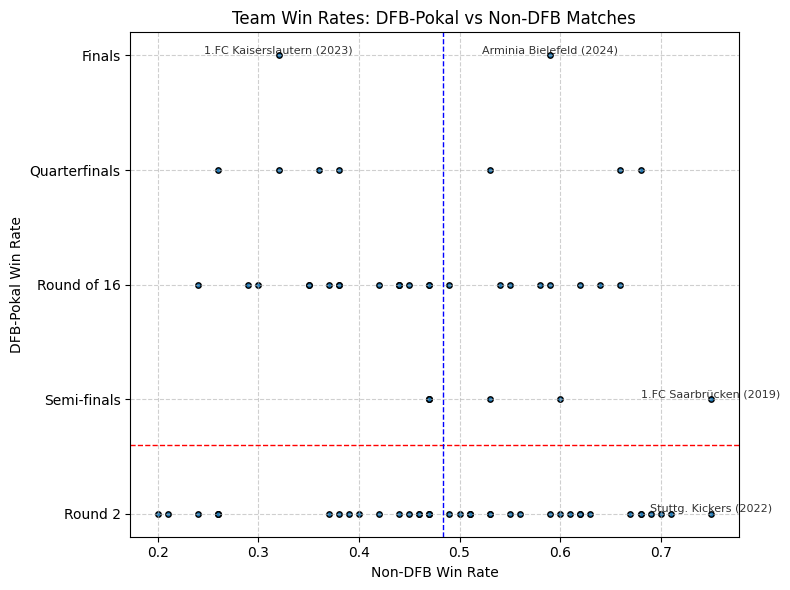

In [3]:
matches = pd.read_csv('datasets/final_datasets/cleaned_matches.csv')


matches = matches.drop_duplicates(subset=['match_link'], keep='last')

matches = matches.drop(columns=['match_link'])

matches['datetime'] = pd.to_datetime(matches['datetime'], errors='coerce')

matches = matches.sort_values(by='datetime', ascending=True).reset_index(drop=True)

winning_rates = []

for index, row in winning_cases.iterrows():
    selected_match = row
    if selected_match['home_score'] > selected_match['away_score']:
        winner_team = selected_match['home_team']
    else:
        winner_team = selected_match['away_team']

    selected_schedule = matches[((matches['home_team'] == winner_team) | (matches['away_team'] == winner_team)) & (matches['season'] == selected_match['season'])].reset_index(drop=True)
    dfb_schedule = selected_schedule[selected_schedule['competition'] == 'DFB-Pokal'].reset_index(drop=True)

    # Calculate win rate in dfb_schedule for the winner_team
    total_matches = dfb_schedule.shape[0]
    wins = ((dfb_schedule['home_team'] == winner_team) & (dfb_schedule['home_score'] > dfb_schedule['away_score'])) | \
        ((dfb_schedule['away_team'] == winner_team) & (dfb_schedule['away_score'] > dfb_schedule['home_score']))
    win_count = wins.sum()
    dfb_win_rate = win_count / total_matches if total_matches > 0 else 0

    # Exclude DFB-Pokal matches
    non_dfb_schedule = selected_schedule[selected_schedule['competition'] != 'DFB-Pokal'].reset_index(drop=True)

    # Calculate win rate in non-DFB-Pokal matches for the winner_team
    total_non_dfb_matches = non_dfb_schedule.shape[0]
    non_dfb_wins = ((non_dfb_schedule['home_team'] == winner_team) & (non_dfb_schedule['home_score'] > non_dfb_schedule['away_score'])) | \
        ((non_dfb_schedule['away_team'] == winner_team) & (non_dfb_schedule['away_score'] > non_dfb_schedule['home_score']))
    non_dfb_win_count = non_dfb_wins.sum()
    non_dfb_win_rate = non_dfb_win_count / total_non_dfb_matches if total_non_dfb_matches > 0 else 0
    winning_rates.append({
        'team': winner_team,
        'season': selected_match['season'],
        'dfb_win_rate': round(dfb_win_rate, 2),
        'non_dfb_win_rate': round(non_dfb_win_rate, 2)
    })

winning_rates = pd.DataFrame(winning_rates).drop_duplicates().reset_index(drop=True)

winning_rates['dfb_win_round'] = winning_rates['dfb_win_rate'].replace({0.5:"Round 2", 0.67:"Round of 16", 0.75:"Quarterfinals", 0.8:"Semi-finals", 0.83:"Finals"})

plt.figure(figsize=(8, 6))
plt.scatter(
    winning_rates['non_dfb_win_rate'],
    winning_rates['dfb_win_round'],
    s=15,
    edgecolor='black',
    color='tab:blue'
)

# Find top 2 teams for highest dfb_win_rate (vertical) and top 2 for highest non_dfb_win_rate (horizontal)
top2_dfb = winning_rates.nlargest(2, 'dfb_win_rate')
top2_non_dfb = winning_rates.nlargest(2, 'non_dfb_win_rate')

# Combine and drop duplicates (in case of overlap)
label_points = pd.concat([top2_dfb, top2_non_dfb]).drop_duplicates(subset=['team', 'season'])

# Label only these points
for _, row in label_points.iterrows():
    plt.text(
        row['non_dfb_win_rate'],
        row['dfb_win_round'],
        f"{row['team']} ({row['season']})",
        fontsize=8,
        ha='center',
        va='bottom',
        color='black',
        alpha=0.8
    )

# Draw average lines for the data in the plot
avg_dfb = winning_rates['dfb_win_rate'].mean()
avg_non_dfb = winning_rates['non_dfb_win_rate'].mean()
plt.axhline(avg_dfb, color='red', linestyle='--', linewidth=1, label='Avg DFB Win Rate')
plt.axvline(avg_non_dfb, color='blue', linestyle='--', linewidth=1, label='Avg Non-DFB Win Rate')

plt.xlabel('Non-DFB Win Rate')
plt.ylabel('DFB-Pokal Win Rate')
plt.title('Team Win Rates: DFB-Pokal vs Non-DFB Matches')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




In [ ]:
# Find all matches where teams from lower divisions played against higher divisions
lower_vs_higher = dfb_matches[dfb_matches['home_division'] != dfb_matches['away_division']].copy()

# For each match, determine if the lower division team was home or away
lower_vs_higher['lower_home'] = lower_vs_higher['home_division'] > lower_vs_higher['away_division']

# Calculate counts
total_lower_vs_higher = lower_vs_higher.shape[0]
lower_home_count = lower_vs_higher['lower_home'].sum()
lower_away_count = total_lower_vs_higher - lower_home_count

# Calculate percentages
lower_home_pct = lower_home_count / total_lower_vs_higher * 100
lower_away_pct = lower_away_count / total_lower_vs_higher * 100

# Extract scores for winning cases
scores_home_wins = winning_cases[winning_cases['home_score'] > winning_cases['away_score']]
scores_away_wins = winning_cases[winning_cases['away_score'] > winning_cases['home_score']]

# Count the number of wins by lower division teams as home and away
home_wins_count = scores_home_wins.shape[0]
away_wins_count = scores_away_wins.shape[0]

# Prepare data for visualization
win_type_counts = pd.DataFrame({
    'Win Type': ['Home Win', 'Away Win'],
    'Count': [home_wins_count, away_wins_count]
})

# Add a second pie chart to the right showing the percentage of lower division teams as home vs away

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Wins by Lower Division Teams (Home vs Away)
axes[0].pie(
    win_type_counts['Count'],
    labels=win_type_counts['Win Type'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4daf4a', '#377eb8']
)
axes[0].set_title('Home/Away Win rates by Lower Division Teams')
axes[0].set_ylabel('')
axes[0].set_xlabel('')
axes[0].axis('equal')

# Right: Proportion of Lower vs Higher Division Matches (Home vs Away)
axes[1].pie(
    [lower_home_count, lower_away_count],
    labels=['Home', 'Away'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4daf4a', '#377eb8']
)
axes[1].set_title('Proportion of home/away matches for lower division teams')
axes[1].set_ylabel('')
axes[1].set_xlabel('')
axes[1].axis('equal')

plt.tight_layout()
plt.show()


#### Team Value Differences: Are Bundesliga Starting Line-Ups Significantly More Valuable?

#### Scheduling Pressure: Schedule Overload – Squad Rotation – Team Form

##### Schedule Overload

In [158]:
dfb_matches = pd.read_csv('datasets/final_datasets/dfb_matches.csv')
matches = pd.read_csv('datasets/final_datasets/cleaned_matches.csv')

dfb_matches = dfb_matches.drop(columns=['match_link'])
dfb_matches['datetime'] = pd.to_datetime(dfb_matches['datetime'])
matches['datetime'] = pd.to_datetime(matches['datetime'])


In [159]:
def calculate_days_since_last_match(team, current_date):
    # Find previous matches for the given team before current_date
    previous_dates = matches[(matches['home_team'] == team) | 
                                  (matches['away_team'] == team)]
    previous_dates = previous_dates[previous_dates['datetime'] < current_date]
    
    if not previous_dates.empty:
        last_match_date = previous_dates['datetime'].max()
        return (current_date - last_match_date).days
    return None

def calculate_games_in_last_n_days(team, current_date,n):
    # Find matches for the given team before current_date and within the last 7 days
    recent_matches = matches[
        (
            ((matches['home_team'] == team) | (matches['away_team'] == team)) &
            (matches['datetime'] < current_date) &
            (matches['datetime'] >= current_date - pd.Timedelta(days=n))
        )
    ]
    return recent_matches.shape[0]



# Apply function to calculate days since last match for both home and away teams in losses DataFrame
dfb_matches['days_since_last_home_match'] = dfb_matches.apply(lambda row: calculate_days_since_last_match(row['home_team'], row['datetime']), axis=1)
dfb_matches['days_since_last_away_match'] = dfb_matches.apply(lambda row: calculate_days_since_last_match(row['away_team'], row['datetime']), axis=1)

# Apply function to calculate days since last match for both home and away teams in losses DataFrame
dfb_matches['home games in the last week'] = dfb_matches.apply(lambda row: calculate_games_in_last_n_days(row['home_team'], row['datetime'],7), axis=1)
dfb_matches['away games in the last week'] = dfb_matches.apply(lambda row: calculate_games_in_last_n_days(row['away_team'], row['datetime'],7), axis=1)


dfb_matches['home games in the last 14 days'] = dfb_matches.apply(lambda row: calculate_games_in_last_n_days(row['home_team'], row['datetime'],14), axis=1)
dfb_matches['away games in the last 14 days'] = dfb_matches.apply(lambda row: calculate_games_in_last_n_days(row['away_team'], row['datetime'],14), axis=1)

dfb_matches['home games in the last 21 days'] = dfb_matches.apply(lambda row: calculate_games_in_last_n_days(row['home_team'], row['datetime'],21), axis=1)
dfb_matches['away games in the last 21 days'] = dfb_matches.apply(lambda row: calculate_games_in_last_n_days(row['away_team'], row['datetime'],21), axis=1)


dfb_matches['days_since_last_home_match'] = dfb_matches['days_since_last_home_match'].apply(
    lambda x: 100 if pd.isnull(x) else x
)
dfb_matches['days_since_last_away_match'] = dfb_matches['days_since_last_away_match'].apply(
    lambda x: 100 if pd.isnull(x) else x
)

# Calculate rest day and games in last week differences for Bundesliga vs lower division matches in each round
dfb_matches['rest_days_diff'] = (
    dfb_matches.apply(
        lambda row: row['days_since_last_home_match'] - row['days_since_last_away_match']
        if row['home_division'] == 1 and row['away_division'] > 1
        else row['days_since_last_away_match'] - row['days_since_last_home_match']
        if row['away_division'] == 1 and row['home_division'] > 1
        else np.nan,
        axis=1
    )
)

dfb_matches['games_last_week_diff'] = (
    dfb_matches.apply(
        lambda row: row['home games in the last week'] - row['away games in the last week']
        if row['home_division'] == 1 and row['away_division'] > 1
        else row['away games in the last week'] - row['home games in the last week']
        if row['away_division'] == 1 and row['home_division'] > 1
        else np.nan,
        axis=1
    )
)

dfb_matches['games_last_2weeks_diff'] = (
    dfb_matches.apply(
        lambda row: row['home games in the last 14 days'] - row['away games in the last 14 days']
        if row['home_division'] == 1 and row['away_division'] > 1
        else row['away games in the last 14 days'] - row['home games in the last 14 days']
        if row['away_division'] == 1 and row['home_division'] > 1
        else np.nan,
        axis=1
    )
)

dfb_matches['games_last_3weeks_diff'] = (
    dfb_matches.apply(
        lambda row: row['home games in the last 21 days'] - row['away games in the last 21 days']
        if row['home_division'] == 1 and row['away_division'] > 1
        else row['away games in the last 21 days'] - row['home games in the last 21 days']
        if row['away_division'] == 1 and row['home_division'] > 1
        else np.nan,
        axis=1
    )
)


bundesliga_matches = dfb_matches[
    ((dfb_matches['home_division'] == 1) & (dfb_matches['away_division'] > 1)) |
    ((dfb_matches['away_division'] == 1) & (dfb_matches['home_division'] > 1))
].reset_index(drop=True)


# Get matches where Bundesliga teams (division 1) lost against lower division teams
buli_loss_df = bundesliga_matches[
    ((bundesliga_matches['home_score'] < bundesliga_matches['away_score']) & (bundesliga_matches['home_division'] == 1)) |
    ((bundesliga_matches['away_score'] < bundesliga_matches['home_score']) & (bundesliga_matches['away_division'] == 1))
].reset_index(drop=True)

# Get matches where Bundesliga teams (division 1) won against lower division teams
buli_win_df = bundesliga_matches[
    ((bundesliga_matches['home_score'] > bundesliga_matches['away_score']) & (bundesliga_matches['home_division'] == 1)) |
    ((bundesliga_matches['away_score'] > bundesliga_matches['home_score']) & (bundesliga_matches['away_division'] == 1))
].reset_index(drop=True)


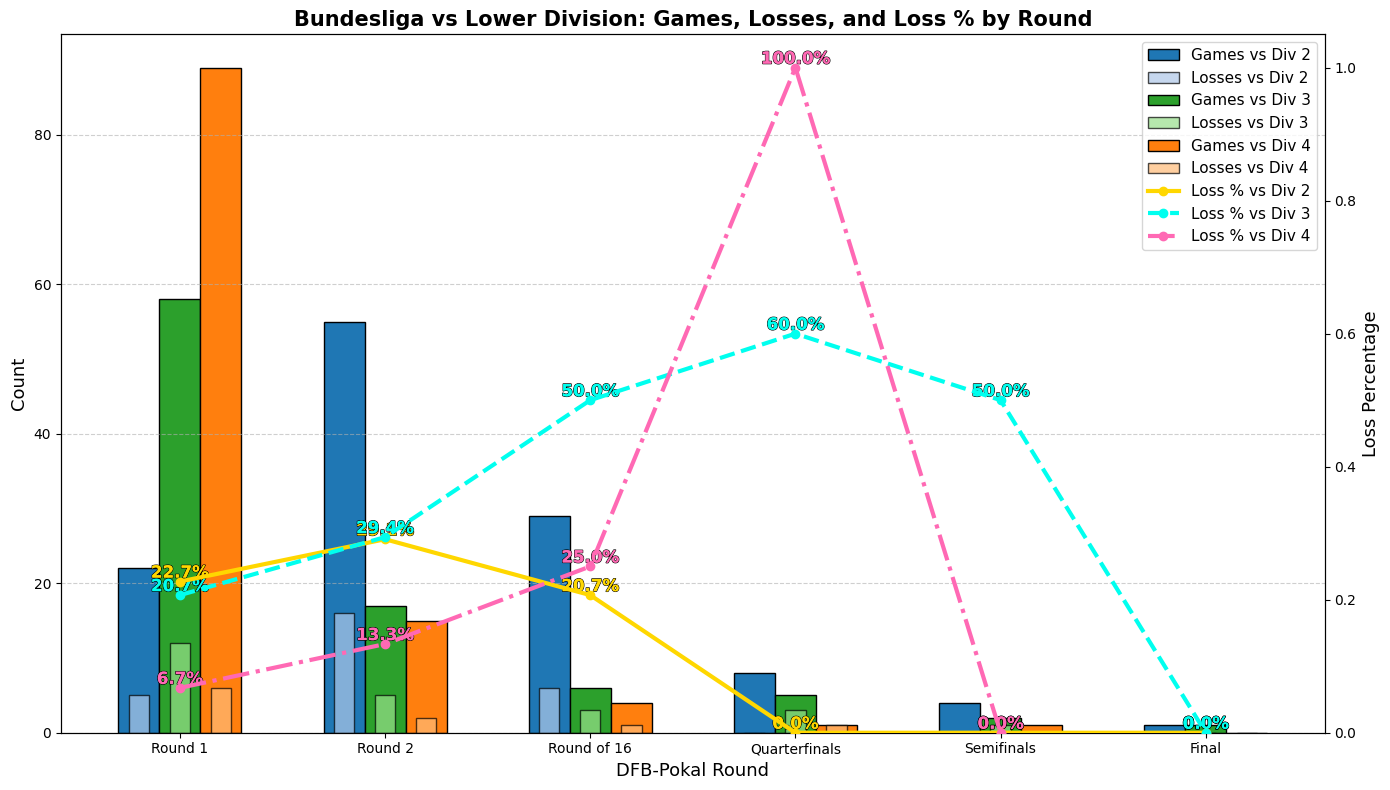

In [160]:
# Define colors for each division (customize as needed)
div_colors = {
    2: "#1f77b4",  # blue
    3: "#2ca02c",  # green
    4: "#ff7f0e",  # orange
}
loss_colors = {
    2: "#aec7e8",  # light blue
    3: "#98df8a",  # light green
    4: "#ffbb78",  # light orange
}

# Prepare all possible opponent divisions (excluding Bundesliga itself)
opponent_divisions = sorted(
    pd.concat([
        dfb_matches['home_division'],
        dfb_matches['away_division']
    ]).unique()
)
opponent_divisions = [div for div in opponent_divisions if div != 1]

round_stats = []

for rnd, group in dfb_matches.groupby('round'):
    # Only consider matches in this round where a Bundesliga team plays a lower division team
    bundesliga_matches = group[
        ((group['home_division'] == 1) & (group['away_division'] != 1)) |
        ((group['away_division'] == 1) & (group['home_division'] != 1))
    ]
    total_games = bundesliga_matches.shape[0]

    # Losses: Bundesliga team loses to lower division
    losses = (
        ((bundesliga_matches['home_division'] == 1) & (bundesliga_matches['home_score'] < bundesliga_matches['away_score'])) |
        ((bundesliga_matches['away_division'] == 1) & (bundesliga_matches['away_score'] < bundesliga_matches['home_score']))
    )
    total_losses = losses.sum()

    # Count games and losses against each division
    games_vs_div = {}
    losses_vs_div = {}
    for div in opponent_divisions:
        games = (
            ((bundesliga_matches['home_division'] == 1) & (bundesliga_matches['away_division'] == div)) |
            ((bundesliga_matches['away_division'] == 1) & (bundesliga_matches['home_division'] == div))
        )
        games_vs_div[f'games_vs_div_{div}'] = games.sum()

        losses_div = (
            ((bundesliga_matches['home_division'] == 1) & (bundesliga_matches['away_division'] == div) & (bundesliga_matches['home_score'] < bundesliga_matches['away_score'])) |
            ((bundesliga_matches['away_division'] == 1) & (bundesliga_matches['home_division'] == div) & (bundesliga_matches['away_score'] < bundesliga_matches['home_score']))
        )
        losses_vs_div[f'losses_vs_div_{div}'] = losses_div.sum()

    round_stats.append({
        'round': rnd,
        'buli_vs_lower_games': total_games,
        'buli_losses_to_lower': total_losses,
        **games_vs_div,
        **losses_vs_div
    })

round_stats_df = pd.DataFrame(round_stats)


# Plot distribution of Bundesliga vs lower division games and losses by round, split by division
fig, ax1 = plt.subplots(figsize=(14, 8))
rounds = round_stats_df['round']
x = np.arange(len(round_stats_df))  # Add this line to define x
bar_width = 0.2  # Define bar width for grouped bars

# Bar plots for games and losses
for i, div in enumerate(opponent_divisions):
    games_col = f'games_vs_div_{div}'
    losses_col = f'losses_vs_div_{div}'
    ax1.bar(x + (i - 1) * bar_width, round_stats_df[games_col], width=bar_width, label=f'Games vs Div {div}', color=div_colors[div], edgecolor='black')
    ax1.bar(x + (i - 1) * bar_width, round_stats_df[losses_col], width=bar_width/2, label=f'Losses vs Div {div}', color=loss_colors[div], edgecolor='black', alpha=0.7)

ax1.set_xlabel('DFB-Pokal Round', fontsize=13)
ax1.set_ylabel('Count', fontsize=13)
ax1.set_title('Bundesliga vs Lower Division: Games, Losses, and Loss % by Round', fontsize=15, weight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(rounds)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Add loss percentage lines for each division
ax2 = ax1.twinx()
line_styles = ['-', '--', '-.']
line_colors = ['#FFD700', '#00FFEF', '#FF69B4']  # Bright and shiny: gold, cyan, hot pink

for i, div in enumerate(opponent_divisions):
    games_col = f'games_vs_div_{div}'
    losses_col = f'losses_vs_div_{div}'
    pct = round_stats_df[losses_col] / round_stats_df[games_col].replace(0, np.nan)
    line, = ax2.plot(
        x, pct, marker='o',
        color=line_colors[i % len(line_colors)],
        linewidth=3, linestyle=line_styles[i % len(line_styles)],
        label=f'Loss % vs Div {div}', zorder=10
    )
    # Annotate percentage values in bold, stagger vertically to avoid overlap, with white shadow for visibility
    for xi, yi in zip(x, pct):
        if not np.isnan(yi):
            # Stagger annotations by division index to avoid overlap
            vertical_offset = 0
            ax2.text(
                xi, yi + vertical_offset, f"{yi:.1%}",
                ha='center', va='bottom', fontsize=12,
                color=line_colors[i % len(line_colors)],
                fontweight='bold',
                path_effects=[
                    matplotlib.patheffects.withStroke(linewidth=1, foreground="black"),
                    matplotlib.patheffects.Normal()
                ]
            )

ax2.set_ylabel('Loss Percentage', fontsize=13)
ax2.set_ylim(0, 1.05)

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper right', fontsize=11)
ax1.set_xticklabels([{
    1: "Round 1",
    2: "Round 2",
    3: "Round of 16",
    4: "Quarterfinals",
    5: "Semifinals",
    6: "Final"
}.get(r, str(r)) for r in rounds])

plt.tight_layout()
plt.show()



In [161]:
# For each round, find the most frequent (mode) month(s) in which matches were held
dfb_matches['month'] = dfb_matches['datetime'].dt.month

def month_full_names(modes):
    return [calendar.month_name[m] for m in modes]

round_month_modes = (
    dfb_matches.groupby('round')['month']
    .agg(lambda x: month_full_names(x.mode().tolist()))
    .reset_index()
    .rename(columns={'month': 'mode_months'})
)

# Join the list into a string (e.g., "August" or "August, September")
round_month_modes['mode_months'] = round_month_modes['mode_months'].apply(lambda x: ', '.join(x))

###### TODO: check the fifa day dates

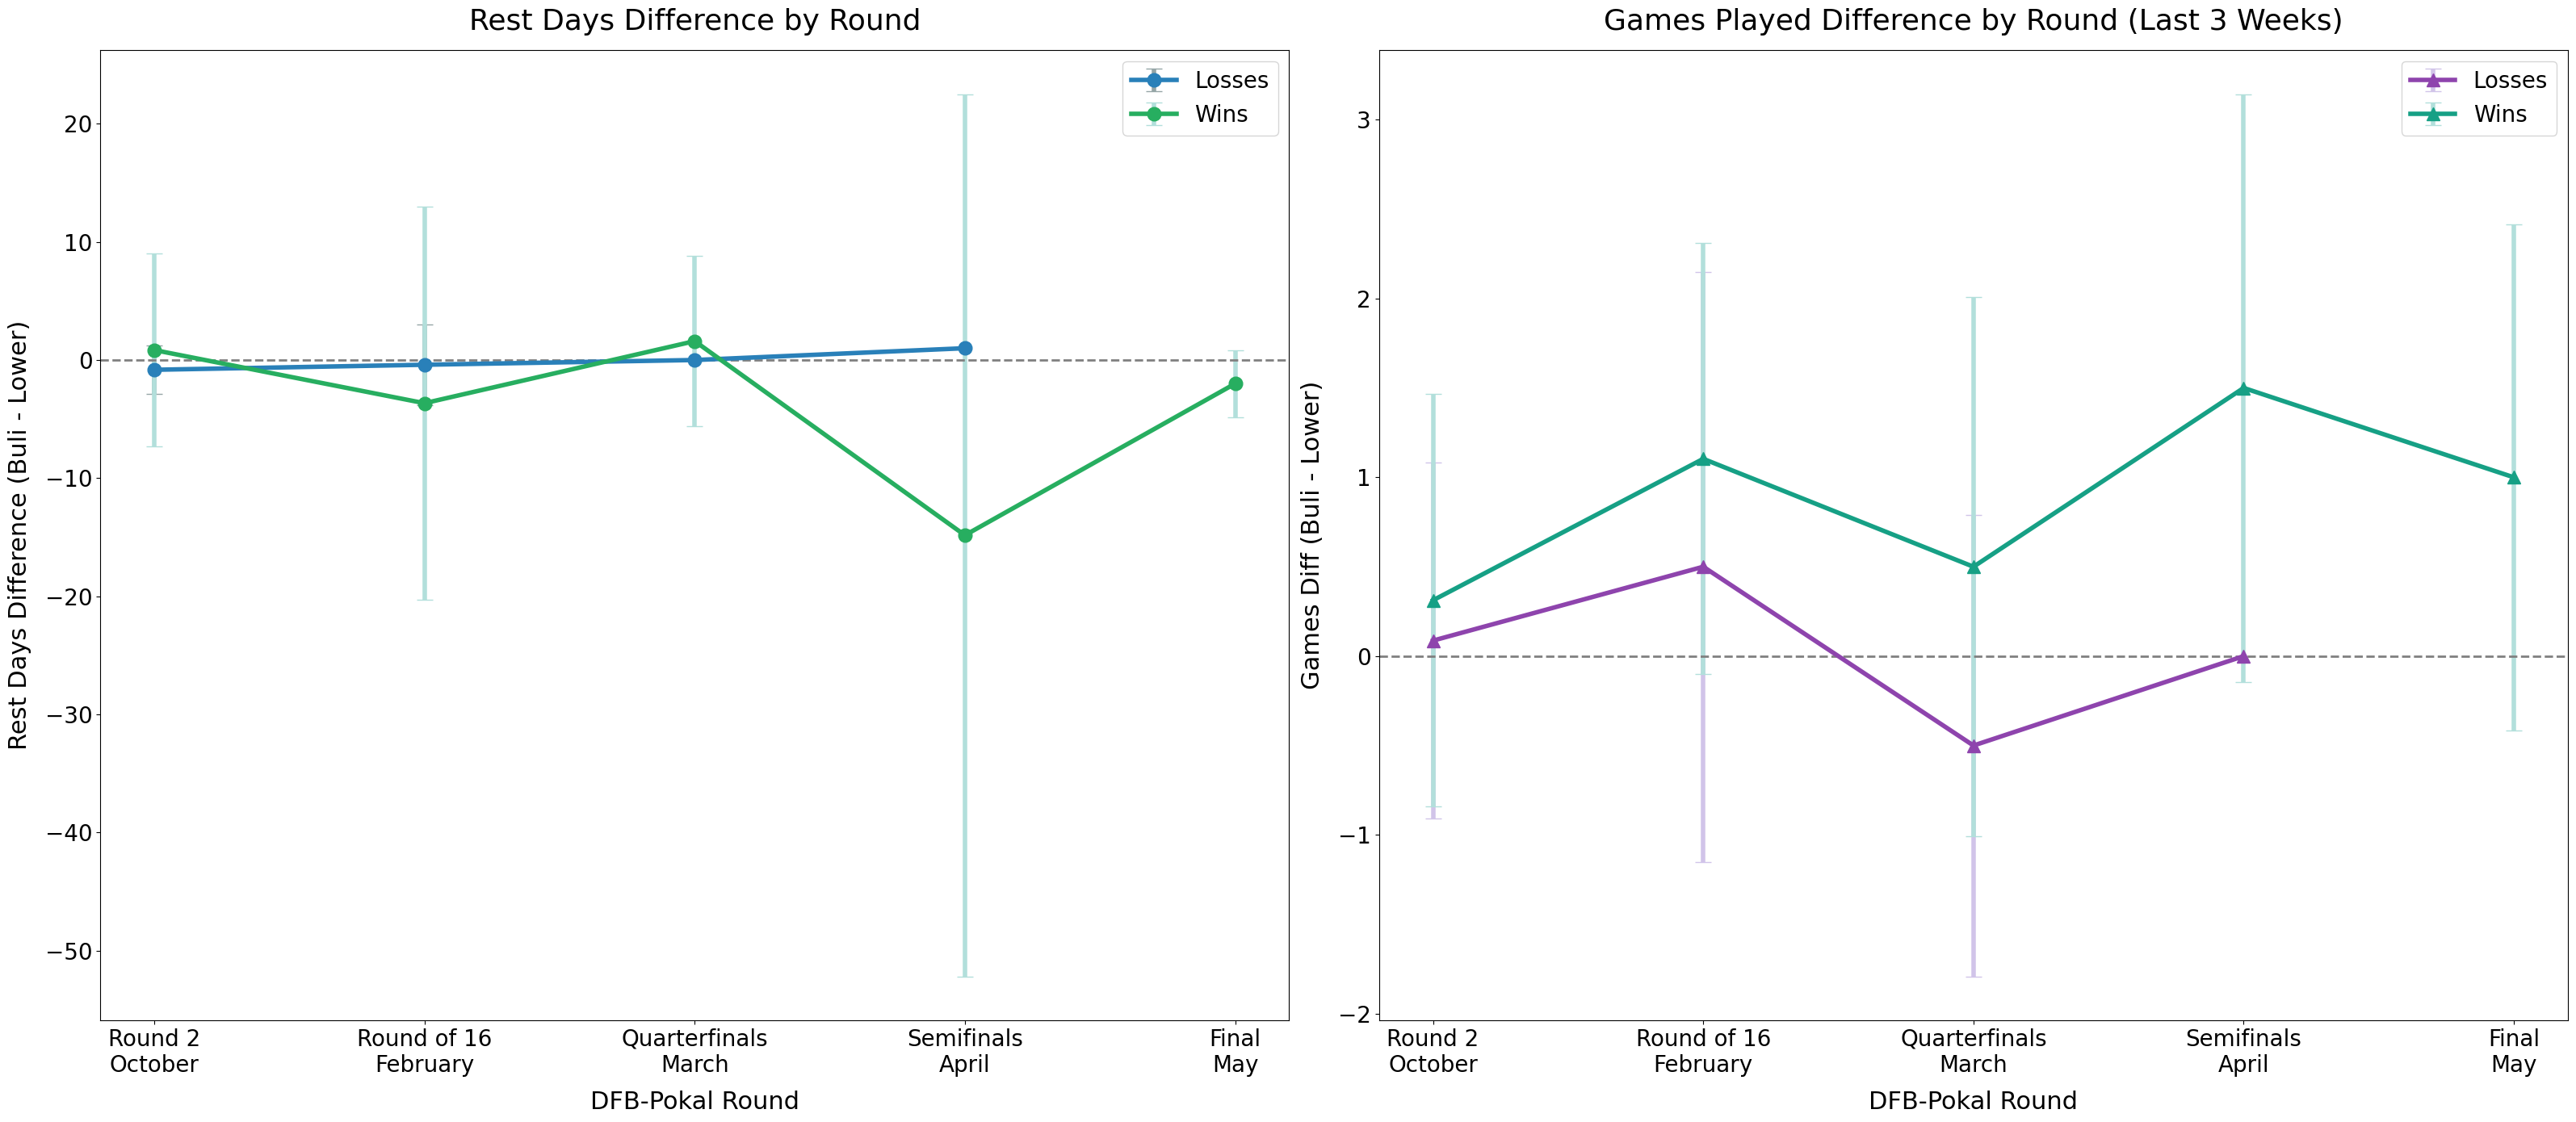

In [162]:
# Group by round and calculate mean and std
buli_loss_rest_days_stats = buli_loss_df.groupby('round')['rest_days_diff'].agg(['mean', 'std']).reset_index()
buli_loss_games_last_week_stats = buli_loss_df.groupby('round')['games_last_week_diff'].agg(['mean', 'std']).reset_index()
buli_loss_games_last_2weeks_stats = buli_loss_df.groupby('round')['games_last_2weeks_diff'].agg(['mean', 'std']).reset_index()
buli_loss_games_last_3weeks_stats = buli_loss_df.groupby('round')['games_last_3weeks_diff'].agg(['mean', 'std']).reset_index()

buli_win_rest_days_stats = buli_win_df.groupby('round')['rest_days_diff'].agg(['mean', 'std']).reset_index()
buli_win_games_last_week_stats = buli_win_df.groupby('round')['games_last_week_diff'].agg(['mean', 'std']).reset_index()
buli_win_games_last_2weeks_stats = buli_win_df.groupby('round')['games_last_2weeks_diff'].agg(['mean', 'std']).reset_index()
buli_win_games_last_3weeks_stats = buli_win_df.groupby('round')['games_last_3weeks_diff'].agg(['mean', 'std']).reset_index()

# Define months_win from round_month_modes if not already defined
if 'months_win' not in locals():
    months_win = round_month_modes.set_index('round')['mode_months']

# Define xtick_labels_win and xticks_win for rounds 2–6 only
xticks_win = months_win.index[1:]  # rounds 2–6
xtick_labels_win = [f"{dict({2: 'Round 2', 3: 'Round of 16', 4: 'Quarterfinals', 5: 'Semifinals', 6: 'Final'}).get(rnd, rnd)}\n{month}" for rnd, month in months_win[1:].items()]

plt.figure(figsize=(32, 14))

# Set font sizes
label_fontsize = 22
title_fontsize = 26
tick_fontsize = 20
legend_fontsize = 20

# Rest Days Difference by Round (Losses)
plt.subplot(1, 2, 1)
plt.errorbar(
    buli_loss_rest_days_stats[1:]['round'], buli_loss_rest_days_stats[1:]['mean'], yerr=buli_loss_rest_days_stats[1:]['std'],
    fmt='-o', capsize=7, color='#2980b9', ecolor='#95a5a6', label='Losses', markersize=12, linewidth=4
)
plt.errorbar(
    buli_win_rest_days_stats[1:]['round'], buli_win_rest_days_stats[1:]['mean'], yerr=buli_win_rest_days_stats[1:]['std'],
    fmt='-o', capsize=7, color='#27ae60', ecolor='#b2dfdb', label='Wins', markersize=12, linewidth=4
)
plt.axhline(0, color='gray', linestyle='--', linewidth=2)
plt.xlabel('DFB-Pokal Round', fontsize=label_fontsize, labelpad=12)
plt.ylabel('Rest Days Difference (Buli - Lower)', fontsize=label_fontsize, labelpad=12)
plt.title('Rest Days Difference by Round', fontsize=title_fontsize, pad=18)
plt.xticks(xticks_win, xtick_labels_win, fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.legend(fontsize=legend_fontsize, loc='best')

# Games Played Difference by Round (Last 3 Weeks)
plt.subplot(1, 2, 2)
plt.errorbar(
    buli_loss_games_last_3weeks_stats[1:]['round'], buli_loss_games_last_3weeks_stats[1:]['mean'], yerr=buli_loss_games_last_3weeks_stats[1:]['std'],
    fmt='-^', capsize=7, color='#8e44ad', ecolor='#d1c4e9', label='Losses', markersize=12, linewidth=4
)
plt.errorbar(
    buli_win_games_last_3weeks_stats[1:]['round'], buli_win_games_last_3weeks_stats[1:]['mean'], yerr=buli_win_games_last_3weeks_stats[1:]['std'],
    fmt='-^', capsize=7, color='#16a085', ecolor='#b2dfdb', label='Wins', markersize=12, linewidth=4
)
plt.axhline(0, color='gray', linestyle='--', linewidth=2)
plt.xlabel('DFB-Pokal Round', fontsize=label_fontsize, labelpad=12)
plt.ylabel('Games Diff (Buli - Lower)', fontsize=label_fontsize, labelpad=12)
plt.title('Games Played Difference by Round (Last 3 Weeks)', fontsize=title_fontsize, pad=18)
plt.xticks(xticks_win, xtick_labels_win, fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.legend(fontsize=legend_fontsize, loc='best')

plt.tight_layout()
plt.show()



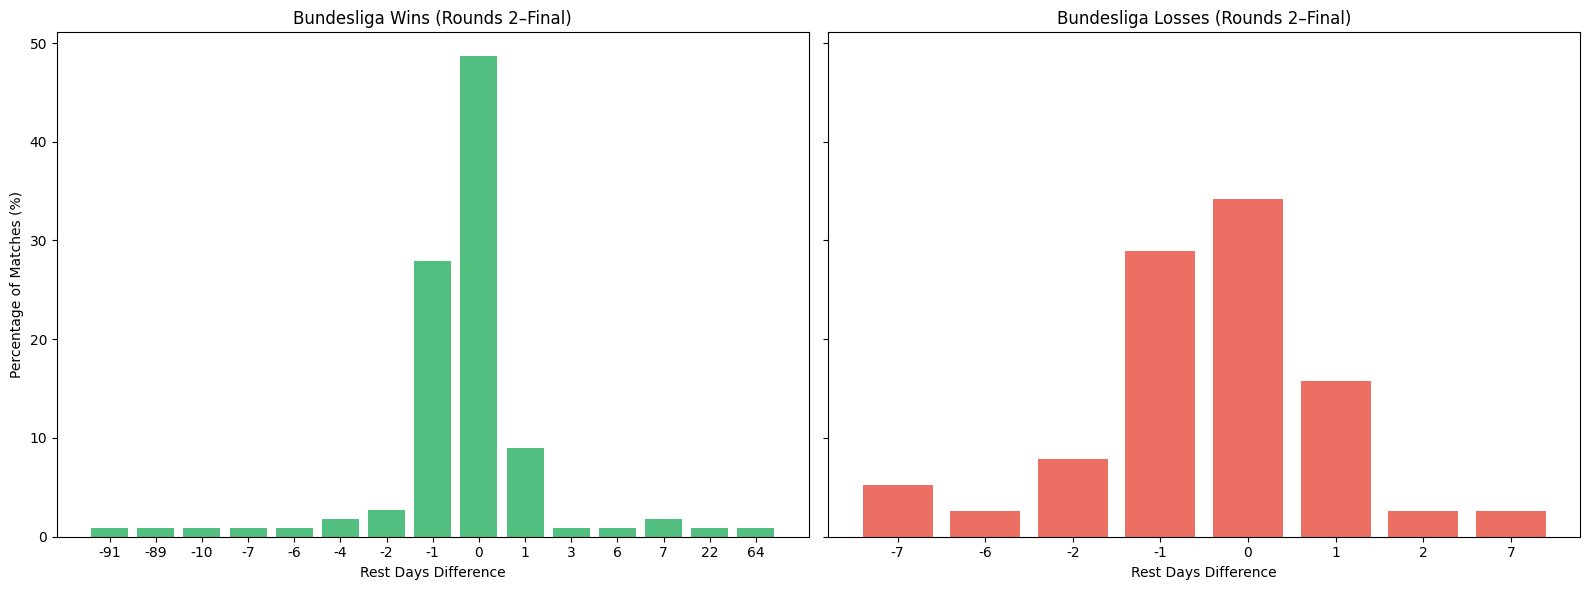

In [164]:
cut_buli_loss_df = buli_loss_df[buli_loss_df['round'] > 1].reset_index(drop=True)
cut_buli_win_df = buli_win_df[buli_win_df['round'] > 1].reset_index(drop=True)

buli_loss_rest_diff = cut_buli_loss_df['rest_days_diff']
buli_win_rest_diff = cut_buli_win_df['rest_days_diff']

buli_loss_3weeks_diff = cut_buli_loss_df['games_last_3weeks_diff']
buli_win_3weeks_diff = cut_buli_win_df['games_last_3weeks_diff']


# Calculate unique values and their percentages
unique_vals_buli_loss, counts_buli_loss = np.unique(buli_loss_rest_diff.dropna(), return_counts=True)
percentages_buli_loss = counts_buli_loss / counts_buli_loss.sum() * 100


unique_vals_buli_win, counts_buli_win = np.unique(buli_win_rest_diff.dropna(), return_counts=True)
percentages_buli_win = counts_buli_win / counts_buli_win.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Left: Bundesliga Wins
axes[0].bar([str(int(v)) for v in unique_vals_buli_win], percentages_buli_win, color='#27ae60', alpha=0.8)
axes[0].set_xlabel('Rest Days Difference')
axes[0].set_ylabel('Percentage of Matches (%)')
axes[0].set_title('Bundesliga Wins (Rounds 2–Final)')

# Right: Bundesliga Losses
axes[1].bar([str(int(v)) for v in unique_vals_buli_loss], percentages_buli_loss, color='#e74c3c', alpha=0.8)
axes[1].set_xlabel('Rest Days Difference')
axes[1].set_title('Bundesliga Losses (Rounds 2–Final)')

plt.tight_layout()
plt.show()

In [170]:
# Calculate Q1 and Q3
q1 = np.percentile(buli_win_3weeks_diff, 25)
q3 = np.percentile(buli_win_3weeks_diff, 75)
iqr = q3 - q1

# Define bounds for non-outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Filter out outliers
filtered_buli_win_3weeks_diff = buli_win_3weeks_diff[(buli_win_3weeks_diff >= lower_bound) & (buli_win_3weeks_diff <= upper_bound)]

# Calculate Q1 and Q3 for losses
q1_loss = np.percentile(buli_loss_3weeks_diff, 25)
q3_loss = np.percentile(buli_loss_3weeks_diff, 75)
iqr_loss = q3_loss - q1_loss

# Define bounds for non-outliers for losses
lower_bound_loss = q1_loss - 1.5 * iqr_loss
upper_bound_loss = q3_loss + 1.5 * iqr_loss

# Filter out outliers for losses
filtered_buli_loss_3weeks_diff = buli_loss_3weeks_diff[(buli_loss_3weeks_diff >= lower_bound_loss) & (buli_loss_3weeks_diff <= upper_bound_loss)]


# Perform t-test
t_stat, p_val = ttest_ind(filtered_buli_win_3weeks_diff, filtered_buli_loss_3weeks_diff, nan_policy='omit')

print(f"T-test Results (Rest Days Diff, Wins vs Losses, Outliers Removed):")
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.4f}")
print(f"Mean (Wins): {filtered_buli_win_3weeks_diff.mean():.2f}, Mean (Losses): {filtered_buli_loss_3weeks_diff.mean():.2f}")

T-test Results (Rest Days Diff, Wins vs Losses, Outliers Removed):
T-statistic: 2.077, P-value: 0.0396
Mean (Wins): 0.54, Mean (Losses): 0.13


##### Team Form

In [3]:
dfb_matches = pd.read_csv('datasets/final_datasets/dfb_matches.csv')
matches = pd.read_csv('datasets/final_datasets/cleaned_matches.csv')

def last_10_matches_same_season(team, match_date, season, matches):
    # Filter matches before the given match_date for the team (home or away)
    team_matches = matches[
        (((matches['home_team'] == team) | (matches['away_team'] == team)) &
         (pd.to_datetime(matches['datetime'], errors='coerce') < match_date))
    ].copy()
    team_matches['datetime'] = pd.to_datetime(team_matches['datetime'], errors='coerce')
    team_matches = team_matches.sort_values(by='datetime', ascending=False).head(10)
    # If any of the last 10 matches is not in the same season, return False
    return all(team_matches['season'] == season) if not team_matches.empty else False

# Ensure datetime columns are in datetime format
dfb_matches['datetime'] = pd.to_datetime(dfb_matches['datetime'], errors='coerce')
matches['datetime'] = pd.to_datetime(matches['datetime'], errors='coerce')

mask = dfb_matches.apply(
    lambda row: last_10_matches_same_season(row['home_team'], row['datetime'], row['season'], matches) and
                last_10_matches_same_season(row['away_team'], row['datetime'], row['season'], matches),
    axis=1
)
dfb_matches = dfb_matches[mask].reset_index(drop=True)

In [4]:
def calculate_team_form(team, match_date, matches, n=10):
    # Filter matches before the given match_date for the team (home or away)
    # Only include matches within the last 3 months (90 days) before match_date
    time_window = pd.Timedelta(days=90)
    team_matches = matches[
        (((matches['home_team'] == team) | (matches['away_team'] == team)) &
         (matches['datetime'] < match_date) &
         (matches['datetime'] >= match_date - time_window))
    ].sort_values(by='datetime', ascending=False).head(n)

    points = 0
    for _, row in team_matches.iterrows():
        if row['home_team'] == team:
            if row['home_score'] > row['away_score']:
                points += 3
            elif row['home_score'] == row['away_score']:
                points += 1
        elif row['away_team'] == team:
            if row['away_score'] > row['home_score']:
                points += 3
            elif row['away_score'] == row['home_score']:
                points += 1
    return points

# Ensure datetime columns are in datetime format
dfb_matches['datetime'] = pd.to_datetime(dfb_matches['datetime'])
matches['datetime'] = pd.to_datetime(matches['datetime'])

dfb_matches['home_team_form'] = dfb_matches.apply(
    lambda row: calculate_team_form(row['home_team'], row['datetime'], matches), axis=1
)
dfb_matches['away_team_form'] = dfb_matches.apply(
    lambda row: calculate_team_form(row['away_team'], row['datetime'], matches), axis=1
)

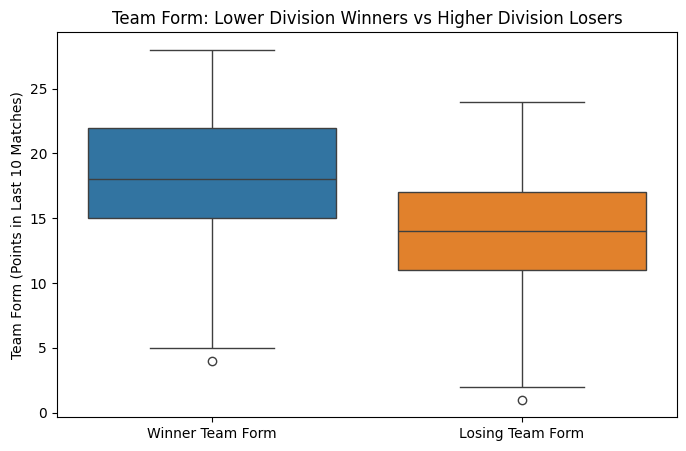

In [5]:
# Select matches where teams from higher divisions won against lower divisions
lower_win_matches = dfb_matches[
    ((dfb_matches['home_division'] > dfb_matches['away_division']) & (dfb_matches['home_score'] > dfb_matches['away_score'])) |
    ((dfb_matches['away_division'] > dfb_matches['home_division']) & (dfb_matches['away_score'] > dfb_matches['home_score']))
]



# Collect winner and loser team forms
winner_forms = []
loser_forms = []

for _, row in lower_win_matches.iterrows():
    if row['home_division'] > row['away_division'] and row['home_score'] > row['away_score']:
        winner_forms.append(row['home_team_form'])
        loser_forms.append(row['away_team_form'])
    elif row['away_division'] > row['home_division'] and row['away_score'] > row['home_score']:
        winner_forms.append(row['away_team_form'])
        loser_forms.append(row['home_team_form'])


# Create DataFrame for plotting
form_df = pd.DataFrame({
    'Winner Team Form': winner_forms,
    'Losing Team Form': loser_forms
})

plt.figure(figsize=(8, 5))
sns.boxplot(data=form_df)
plt.title('Team Form: Lower Division Winners vs Higher Division Losers')
plt.ylabel('Team Form (Points in Last 10 Matches)')
plt.show()

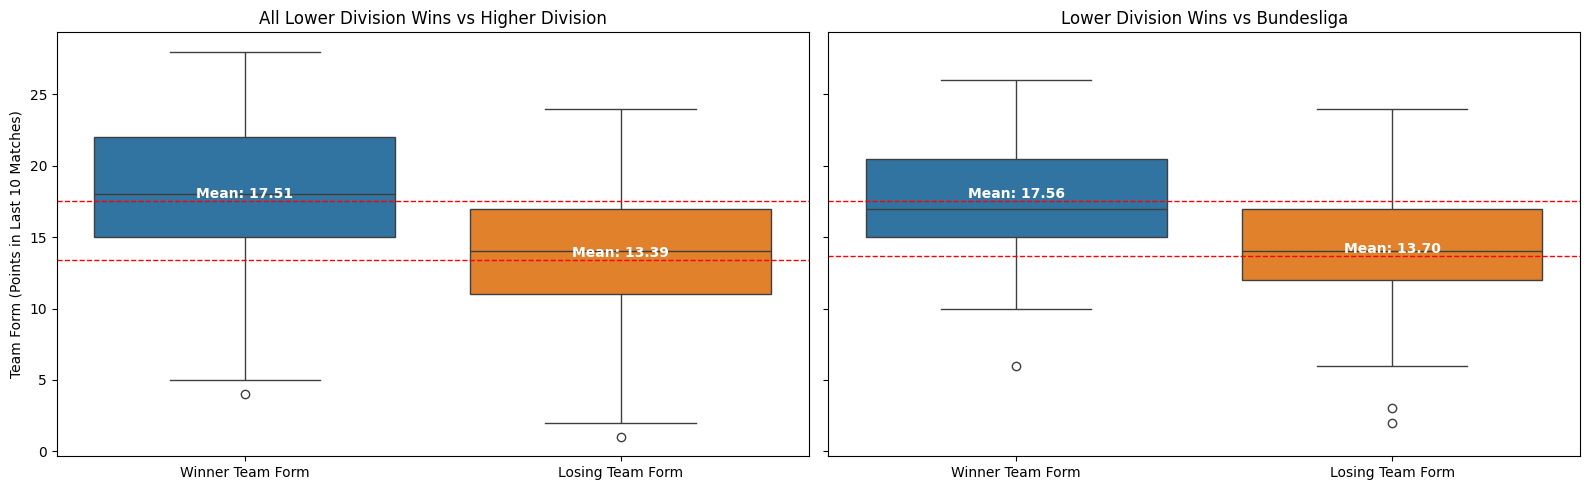

In [6]:
# Select DFB matches where a lower division team won against a higher division team
dfb_lower_win = dfb_matches[
    ((dfb_matches['home_division'] > dfb_matches['away_division']) & (dfb_matches['home_score'] > dfb_matches['away_score'])) |
    ((dfb_matches['away_division'] > dfb_matches['home_division']) & (dfb_matches['away_score'] > dfb_matches['home_score']))
]

dfb_lower_vs_buli = dfb_lower_win[
    ((dfb_lower_win['home_division'] == 1) & (dfb_lower_win['away_division'] > 1)) |
    ((dfb_lower_win['away_division'] == 1) & (dfb_lower_win['home_division'] > 1))
]



# Determine winner and loser team form for each match
winner_form = []
loser_form = []
winner_form2 = []
loser_form2 = []

for _, row in dfb_lower_win.iterrows():
    if row['home_division'] > row['away_division'] and row['home_score'] > row['away_score']:
        winner_form.append(row['home_team_form'])
        loser_form.append(row['away_team_form'])
    elif row['away_division'] > row['home_division'] and row['away_score'] > row['home_score']:
        winner_form.append(row['away_team_form'])
        loser_form.append(row['home_team_form'])

for _, row in dfb_lower_vs_buli.iterrows():
    if row['home_division'] > row['away_division'] and row['home_score'] > row['away_score']:
        winner_form2.append(row['home_team_form'])
        loser_form2.append(row['away_team_form'])
    elif row['away_division'] > row['home_division'] and row['away_score'] > row['home_score']:
        winner_form2.append(row['away_team_form'])
        loser_form2.append(row['home_team_form'])

# Create DataFrame for plotting
form_df = pd.DataFrame({
    'Winner Team Form': winner_form,
    'Losing Team Form': loser_form
})

form_df2 = pd.DataFrame({
    'Winner Team Form': winner_form2,
    'Losing Team Form': loser_form2
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Plot 1: All Lower Division Wins vs Higher Division
sns.boxplot(data=form_df, ax=axes[0])
axes[0].set_title('All Lower Division Wins vs Higher Division')
axes[0].set_ylabel('Team Form (Points in Last 10 Matches)')

# Calculate and annotate means for plot 1
means1 = form_df.mean()
for i, col in enumerate(form_df.columns):
    axes[0].axhline(means1[col], color='red', linestyle='--', linewidth=1)
    axes[0].text(i, means1[col], f"Mean: {means1[col]:.2f}", color='white', va='bottom', ha='center', fontsize=10, fontweight='bold')

# Plot 2: Lower Division Wins vs Bundesliga
sns.boxplot(data=form_df2, ax=axes[1])
axes[1].set_title('Lower Division Wins vs Bundesliga')
axes[1].set_ylabel('')

# Calculate and annotate means for plot 2
means2 = form_df2.mean()
for i, col in enumerate(form_df2.columns):
    axes[1].axhline(means2[col], color='red', linestyle='--', linewidth=1)
    axes[1].text(i, means2[col], f"Mean: {means2[col]:.2f}", color='white', va='bottom', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

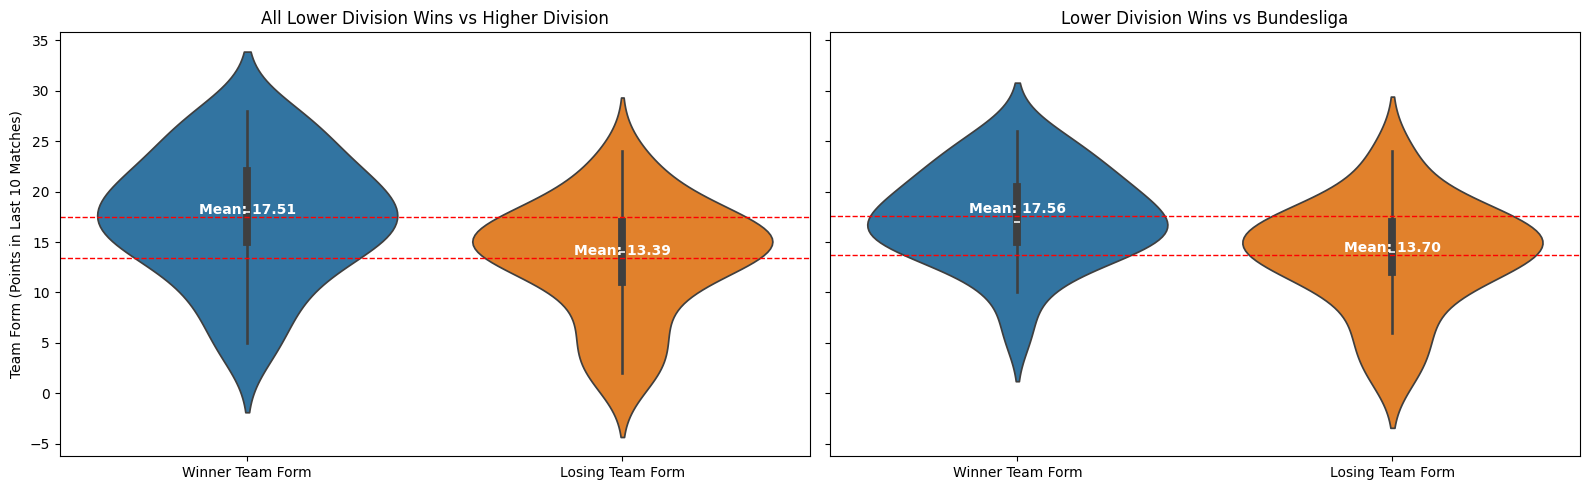

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Plot 1: All Lower Division Wins vs Higher Division
sns.violinplot(data=form_df, ax=axes[0], inner='box')
axes[0].set_title('All Lower Division Wins vs Higher Division')
axes[0].set_ylabel('Team Form (Points in Last 10 Matches)')

# Calculate and annotate means for plot 1
means1 = form_df.mean()
for i, col in enumerate(form_df.columns):
    axes[0].axhline(means1[col], color='red', linestyle='--', linewidth=1)
    axes[0].text(i, means1[col], f"Mean: {means1[col]:.2f}", color='white', va='bottom', ha='center', fontsize=10, fontweight='bold')

# Plot 2: Lower Division Wins vs Bundesliga
sns.violinplot(data=form_df2, ax=axes[1], inner='box')
axes[1].set_title('Lower Division Wins vs Bundesliga')
axes[1].set_ylabel('')

# Calculate and annotate means for plot 2
means2 = form_df2.mean()
for i, col in enumerate(form_df2.columns):
    axes[1].axhline(means2[col], color='red', linestyle='--', linewidth=1)
    axes[1].text(i, means2[col], f"Mean: {means2[col]:.2f}", color='white', va='bottom', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# Perform t-test
t_statistic, p_value = ttest_ind(winner_form, loser_form, nan_policy='omit')

print('T-test Results for Lower Division Wins vs Higher Division:')
# Output results
print(f"T-statistic: {t_statistic:.3f}, P-value: {p_value:.3f}")

# Optional: show means for context
print(f"Winner mean form: {np.mean(winner_form):.2f}, Loser mean form: {np.mean(loser_form):.2f}")

print('--'*50)
print('T-test Results for Lower Division Wins vs Bundesliga:')
# Perform t-test for lower division wins against Bundesliga teams
t_statistic2, p_value2 = ttest_ind(winner_form2, loser_form2, nan_policy='omit')
print(f"T-statistic: {t_statistic2:.3f}, P-value: {p_value2:.3f}")

# Optional: show means for context
print(f"Winner mean form: {np.mean(winner_form2):.2f}, Loser mean form: {np.mean(loser_form2):.2f}")


T-test Results for Lower Division Wins vs Higher Division:
T-statistic: 3.174, P-value: 0.002
Winner mean form: 17.51, Loser mean form: 13.39
----------------------------------------------------------------------------------------------------
T-test Results for Lower Division Wins vs Bundesliga:
T-statistic: 2.868, P-value: 0.006
Winner mean form: 17.56, Loser mean form: 13.70


In both comparisons, winning lower division teams exhibit superior recent performance relative to their counterparts from higher divisions—whether facing other lower division opponents or Bundesliga teams—highlighting how effective current form contributes to their success in cup competitions.

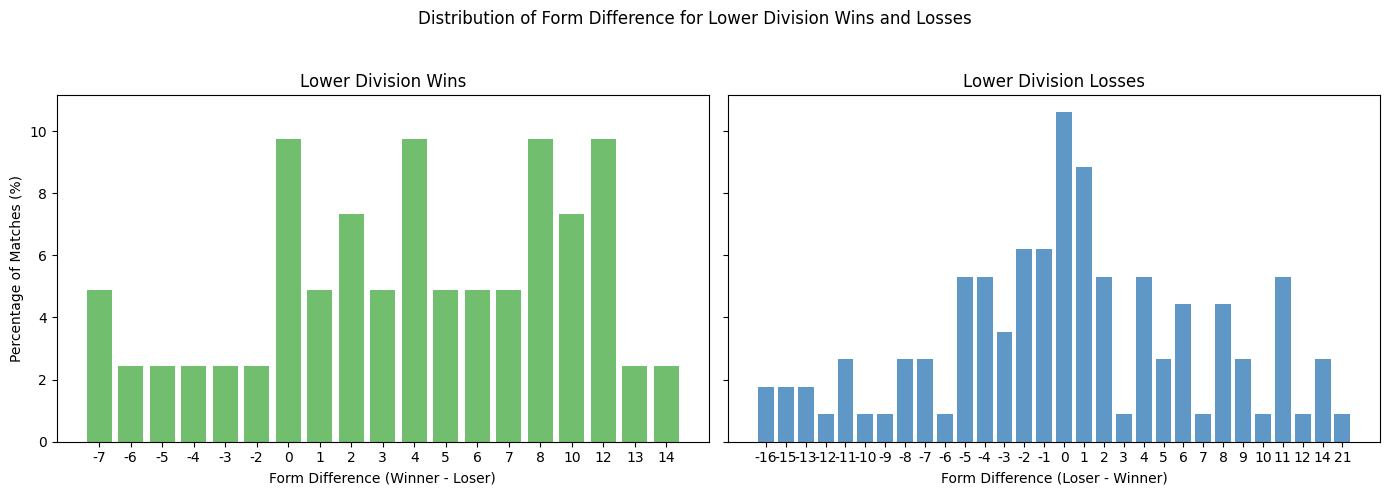

In [9]:
lower_win_matches = dfb_matches[
    ((dfb_matches['home_division'] > dfb_matches['away_division']) & (dfb_matches['home_score'] > dfb_matches['away_score'])) |
    ((dfb_matches['away_division'] > dfb_matches['home_division']) & (dfb_matches['away_score'] > dfb_matches['home_score']))
].reset_index(drop=True)

lower_loss_matches = dfb_matches[
    ((dfb_matches['home_division'] > dfb_matches['away_division']) & (dfb_matches['home_score'] < dfb_matches['away_score'])) |
    ((dfb_matches['away_division'] > dfb_matches['home_division']) & (dfb_matches['away_score'] < dfb_matches['home_score']))
].reset_index(drop=True)

# Calculate form difference (winner form - loser form) for lower_win_matches
lower_win_form_diff = []
for _, row in lower_win_matches.iterrows():
    if row['home_division'] > row['away_division'] and row['home_score'] > row['away_score']:
        diff = row['home_team_form'] - row['away_team_form']
    elif row['away_division'] > row['home_division'] and row['away_score'] > row['home_score']:
        diff = row['away_team_form'] - row['home_team_form']
    else:
        continue
    lower_win_form_diff.append(diff)

# Calculate form difference (loser form - winner form) for lower_loss_matches
lower_loss_form_diff = []
for _, row in lower_loss_matches.iterrows():
    if row['home_division'] > row['away_division'] and row['home_score'] < row['away_score']:
        diff = row['home_team_form'] - row['away_team_form']
    elif row['away_division'] > row['home_division'] and row['away_score'] < row['home_score']:
        diff = row['away_team_form'] - row['home_team_form']
    else:
        continue
    lower_loss_form_diff.append(diff)

# Calculate percentage occurrence for each unique value in lower_win_form_diff
unique_lower_win, counts_lower_win = np.unique(lower_win_form_diff, return_counts=True)
total_win = counts_lower_win.sum()
value_percentages_lower_win = {val: (cnt / total_win) * 100 for val, cnt in zip(unique_lower_win, counts_lower_win)}

# Calculate percentage occurrence for each unique value in lower_loss_form_diff
unique_lower_loss, counts_lower_loss = np.unique(lower_loss_form_diff, return_counts=True)
total_loss = counts_lower_loss.sum()
value_percentages_lower_loss = {val: (cnt / total_loss) * 100 for val, cnt in zip(unique_lower_loss, counts_lower_loss)}


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Plot for lower_win_form_diff
axes[0].bar(
    [str(int(k)) for k in value_percentages_lower_win.keys()],
    value_percentages_lower_win.values(),
    alpha=0.8,
    color='#4daf4a'
)
axes[0].set_xlabel('Form Difference (Winner - Loser)')
axes[0].set_ylabel('Percentage of Matches (%)')
axes[0].set_title('Lower Division Wins')

# Plot for lower_loss_form_diff
axes[1].bar(
    [str(int(k)) for k in value_percentages_lower_loss.keys()],
    value_percentages_lower_loss.values(),
    alpha=0.8,
    color='#377eb8'
)
axes[1].set_xlabel('Form Difference (Loser - Winner)')
axes[1].set_title('Lower Division Losses')

plt.suptitle('Distribution of Form Difference for Lower Division Wins and Losses')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [10]:
lower_win_diff_series = pd.Series(lower_win_form_diff)
lower_loss_diff_series = pd.Series(lower_loss_form_diff)

# Perform t-test comparing schedule differences for wins vs losses
t_statistic, p_value = ttest_ind(lower_win_diff_series, lower_loss_diff_series, nan_policy='omit')

# Output results
print(f"T-statistic: {t_statistic:.3f}, P-value: {p_value:.3f}")

# Optional: show means for context
print(f"Mean Schedule Difference (Wins): {lower_win_diff_series.mean():.2f}, Mean Schedule Difference (Losses): {lower_loss_diff_series.mean():.2f}")

T-statistic: 3.128, P-value: 0.002
Mean Schedule Difference (Wins): 4.12, Mean Schedule Difference (Losses): 0.26


##### Attacking vs Defensive Form

In [37]:
dfb_matches = pd.read_csv('datasets/final_datasets/dfb_matches.csv')
matches = pd.read_csv('datasets/final_datasets/cleaned_matches.csv')

def last_10_matches_same_season(team, match_date, season, matches):
    # Filter matches before the given match_date for the team (home or away)
    team_matches = matches[
        (((matches['home_team'] == team) | (matches['away_team'] == team)) &
         (pd.to_datetime(matches['datetime'], errors='coerce') < match_date))
    ].copy()
    team_matches['datetime'] = pd.to_datetime(team_matches['datetime'], errors='coerce')
    team_matches = team_matches.sort_values(by='datetime', ascending=False).head(10)
    # If any of the last 10 matches is not in the same season, return False
    return all(team_matches['season'] == season) if not team_matches.empty else False

# Ensure datetime columns are in datetime format
dfb_matches['datetime'] = pd.to_datetime(dfb_matches['datetime'], errors='coerce')
matches['datetime'] = pd.to_datetime(matches['datetime'], errors='coerce')

mask = dfb_matches.apply(
    lambda row: last_10_matches_same_season(row['home_team'], row['datetime'], row['season'], matches) and
                last_10_matches_same_season(row['away_team'], row['datetime'], row['season'], matches),
    axis=1
)
dfb_matches = dfb_matches[mask].reset_index(drop=True)

###### Attacking Form

In [38]:
def calculate_last_10_goals(team, match_date):
    # Filter matches before the given match_date for the team (home or away)
    team_matches = matches[
        (((matches['home_team'] == team) | (matches['away_team'] == team)) &
         (pd.to_datetime(matches['datetime'], errors='coerce') < match_date))
    ].copy()
    team_matches['datetime'] = pd.to_datetime(team_matches['datetime'], errors='coerce')
    team_matches = team_matches.sort_values(by='datetime', ascending=False).head(10)

    goals = 0
    for _, row in team_matches.iterrows():
        if row['home_team'] == team:
            goals += row['home_score']
        elif row['away_team'] == team:
            goals += row['away_score']
    try:
        int(goals)
    except ValueError:
        print(True)
    return goals

# Example usage for dfb_matches DataFrame:
dfb_matches['home_attacking_form'] = dfb_matches.apply(
    lambda row: calculate_last_10_goals(row['home_team'], row['datetime']), axis=1
)
dfb_matches['away_attacking_form'] = dfb_matches.apply(
    lambda row: calculate_last_10_goals(row['away_team'], row['datetime']), axis=1
)

In [39]:
higher_win_matches = dfb_matches[
    ((dfb_matches['home_division'] < dfb_matches['away_division']) & (dfb_matches['home_score'] > dfb_matches['away_score'])) |
    ((dfb_matches['away_division'] < dfb_matches['home_division']) & (dfb_matches['away_score'] > dfb_matches['home_score']))
]

lower_win_matches = dfb_matches[
    ((dfb_matches['home_division'] > dfb_matches['away_division']) & (dfb_matches['home_score'] > dfb_matches['away_score'])) |
    ((dfb_matches['away_division'] > dfb_matches['home_division']) & (dfb_matches['away_score'] > dfb_matches['home_score']))
]

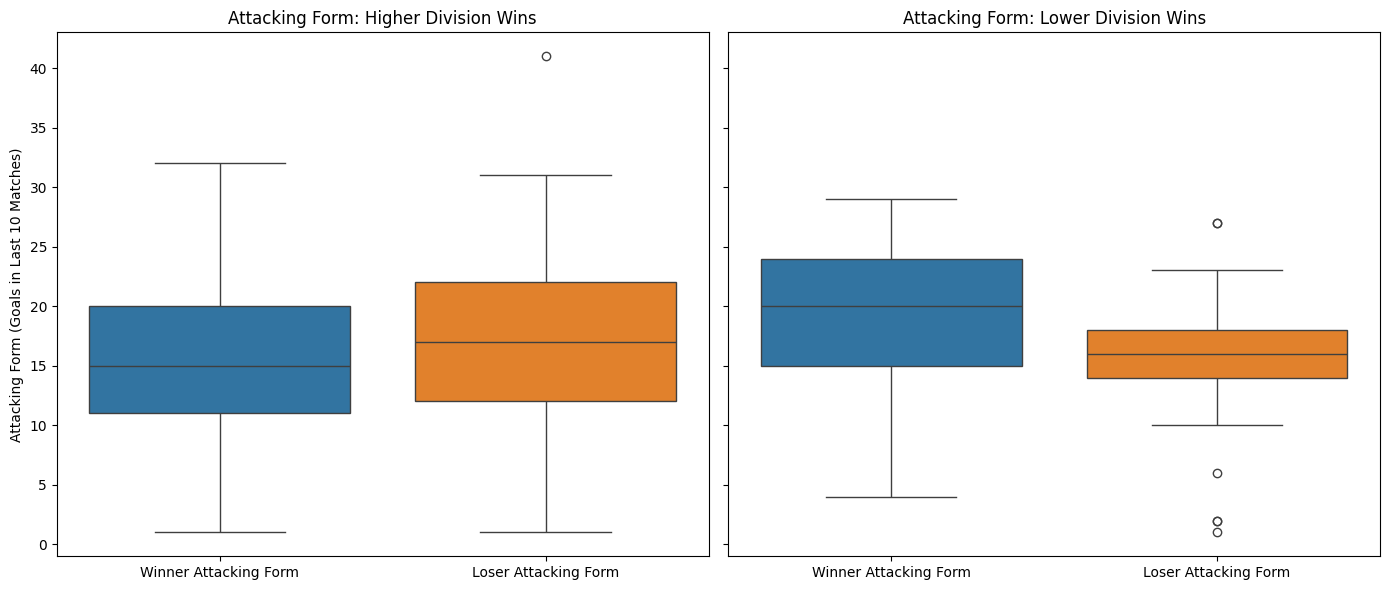

In [40]:
# For higher_win_matches, get attacking forms for both winner and loser teams
higher_win_attacking_forms = []
lower_loss_attacking_forms = []

lower_win_attacking_forms = []
higher_loss_attacking_forms = []

for _, row in higher_win_matches.iterrows():
    if row['home_division'] < row['away_division'] and row['home_score'] > row['away_score']:
        higher_win_attacking_forms.append(row['home_attacking_form'])
        lower_loss_attacking_forms.append(row['away_attacking_form'])
    elif row['away_division'] < row['home_division'] and row['away_score'] > row['home_score']:
        higher_win_attacking_forms.append(row['away_attacking_form'])
        lower_loss_attacking_forms.append(row['home_attacking_form'])
    else:
        continue  # skip draws or invalid rows

for _, row in lower_win_matches.iterrows():
    if row['home_division'] > row['away_division'] and row['home_score'] > row['away_score']:
        lower_win_attacking_forms.append(row['home_attacking_form'])
        higher_loss_attacking_forms.append(row['away_attacking_form'])
    elif row['away_division'] > row['home_division'] and row['away_score'] > row['home_score']:
        lower_win_attacking_forms.append(row['away_attacking_form'])
        higher_loss_attacking_forms.append(row['home_attacking_form'])
    else:
        continue  # skip draws or invalid rows

# Convert to DataFrame for further analysis
higher_attacking_form_df = pd.DataFrame({
    'Winner Attacking Form': higher_win_attacking_forms,
    'Loser Attacking Form': lower_loss_attacking_forms
})

lower_attacking_form_df = pd.DataFrame({
    'Winner Attacking Form': lower_win_attacking_forms,
    'Loser Attacking Form': higher_loss_attacking_forms
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot for higher division wins
sns.boxplot(data=higher_attacking_form_df, ax=axes[0])
axes[0].set_title('Attacking Form: Higher Division Wins')
axes[0].set_ylabel('Attacking Form (Goals in Last 10 Matches)')
axes[0].set_xlabel('')

# Plot for lower division wins
sns.boxplot(data=lower_attacking_form_df, ax=axes[1])
axes[1].set_title('Attacking Form: Lower Division Wins')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

In [41]:
# Perform t-test
t_statistic, p_value = ttest_ind(lower_win_attacking_forms, higher_loss_attacking_forms, nan_policy='omit')

print('T-test Results for Lower Division Wins vs Higher Division:')
# Output results
print(f"T-statistic: {t_statistic:.3f}, P-value: {p_value:.3f}")

# Optional: show means for context
print(f"Winner mean form: {np.mean(lower_win_attacking_forms):.2f}, Loser mean form: {np.mean(higher_loss_attacking_forms):.2f}")

T-test Results for Lower Division Wins vs Higher Division:
T-statistic: 2.632, P-value: 0.010
Winner mean form: 19.10, Loser mean form: 15.46


when lower division teams win their matches, they tend to have a significantly better attacking form compared to the higher division teams they face.

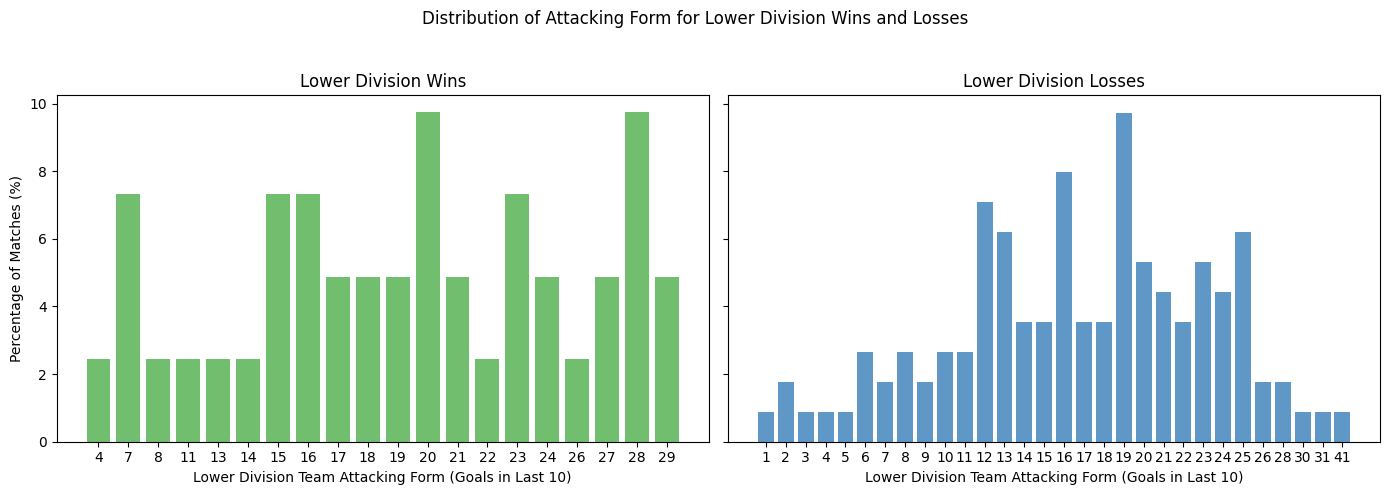

In [43]:
# Calculate attacking form lists for lower_win_matches and lower_loss_matches
# For each match, get the attacking form of the lower division team

# Lower division team attacking form in wins
lower_win_attacking_form = []
for _, row in lower_win_matches.iterrows():
    if row['home_division'] > row['away_division'] and row['home_score'] > row['away_score']:
        lower_win_attacking_form.append(row['home_attacking_form'])
    elif row['away_division'] > row['home_division'] and row['away_score'] > row['home_score']:
        lower_win_attacking_form.append(row['away_attacking_form'])

# Lower division team attacking form in losses
lower_loss_attacking_form = []
for _, row in higher_win_matches.iterrows():
    if row['home_division'] > row['away_division'] and row['home_score'] < row['away_score']:
        lower_loss_attacking_form.append(row['home_attacking_form'])
    elif row['away_division'] > row['home_division'] and row['away_score'] < row['home_score']:
        lower_loss_attacking_form.append(row['away_attacking_form'])

# Count occurrences and calculate percentages for wins
unique_win, counts_win = np.unique(lower_win_attacking_form, return_counts=True)
total_win = counts_win.sum()
percentages_win = {val: (cnt / total_win) * 100 for val, cnt in zip(unique_win, counts_win)}

# Count occurrences and calculate percentages for losses
unique_loss, counts_loss = np.unique(lower_loss_attacking_form, return_counts=True)
total_loss = counts_loss.sum()
percentages_loss = {val: (cnt / total_loss) * 100 for val, cnt in zip(unique_loss, counts_loss)}

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Lower division wins
win_keys = [k for k in percentages_win.keys() if not pd.isna(k)]
axes[0].bar(
    [str(int(k)) for k in win_keys],
    [percentages_win[k] for k in win_keys],
    color='#4daf4a',
    alpha=0.8
)
axes[0].set_xlabel('Lower Division Team Attacking Form (Goals in Last 10)')
axes[0].set_ylabel('Percentage of Matches (%)')
axes[0].set_title('Lower Division Wins')

# Lower division losses
loss_keys = [k for k in percentages_loss.keys() if not pd.isna(k)]
axes[1].bar(
    [str(int(k)) for k in loss_keys],
    [percentages_loss[k] for k in loss_keys],
    color='#377eb8',
    alpha=0.8
)
axes[1].set_xlabel('Lower Division Team Attacking Form (Goals in Last 10)')
axes[1].set_title('Lower Division Losses')

plt.suptitle('Distribution of Attacking Form for Lower Division Wins and Losses')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [44]:
from scipy.stats import ttest_ind

# Perform t-test: lower_win_attacking_form vs lower_loss_attacking_form
t_stat, p_val = ttest_ind(lower_win_attacking_form, lower_loss_attacking_form, nan_policy='omit')

print("T-test Results: Are attacking forms different for lower division wins vs losses?")
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.4f}")
print(f"Mean attacking form (wins): {np.mean(lower_win_attacking_form):.2f}")
print(f"Mean attacking form (losses): {np.mean(lower_loss_attacking_form):.2f}")

T-test Results: Are attacking forms different for lower division wins vs losses?
T-statistic: 1.788, P-value: 0.0758
Mean attacking form (wins): 19.10
Mean attacking form (losses): 16.87


###### Defensive Form

In [48]:
def calculate_last_10_conceded_goals(team, match_date):
    # Filter matches before the given match_date for the team (home or away)
    team_matches = matches[
        (((matches['home_team'] == team) | (matches['away_team'] == team)) &
         (pd.to_datetime(matches['datetime'], errors='coerce') < match_date))
    ].copy()
    team_matches['datetime'] = pd.to_datetime(team_matches['datetime'], errors='coerce')
    team_matches = team_matches.sort_values(by='datetime', ascending=False).head(10)

    conceded = 0
    for _, row in team_matches.iterrows():
        if row['home_team'] == team:
            conceded += row['away_score']
        elif row['away_team'] == team:
            conceded += row['home_score']
    return conceded

dfb_matches['home_conceded_last10'] = dfb_matches.apply(
    lambda row: calculate_last_10_conceded_goals(row['home_team'], row['datetime']), axis=1
)
dfb_matches['away_conceded_last10'] = dfb_matches.apply(
    lambda row: calculate_last_10_conceded_goals(row['away_team'], row['datetime']), axis=1
)



In [49]:
higher_win_matches = dfb_matches[
    ((dfb_matches['home_division'] < dfb_matches['away_division']) & (dfb_matches['home_score'] > dfb_matches['away_score'])) |
    ((dfb_matches['away_division'] < dfb_matches['home_division']) & (dfb_matches['away_score'] > dfb_matches['home_score']))
]

lower_win_matches = dfb_matches[
    ((dfb_matches['home_division'] > dfb_matches['away_division']) & (dfb_matches['home_score'] > dfb_matches['away_score'])) |
    ((dfb_matches['away_division'] > dfb_matches['home_division']) & (dfb_matches['away_score'] > dfb_matches['home_score']))
]

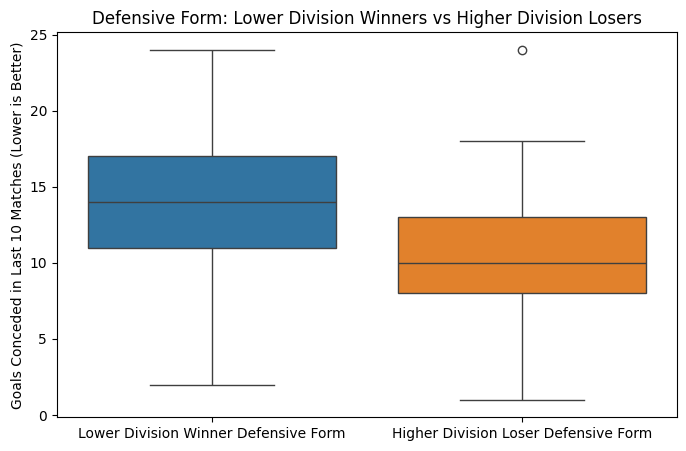

In [50]:
import seaborn as sns

lower_win_defensive_forms = []
higher_loss_defensive_forms = []

for _, row in lower_win_matches.iterrows():
    if row['home_division'] > row['away_division'] and row['home_score'] > row['away_score']:
        lower_win_defensive_forms.append(row['away_conceded_last10'])
        higher_loss_defensive_forms.append(row['home_conceded_last10'])
    elif row['away_division'] > row['home_division'] and row['away_score'] > row['home_score']:
        lower_win_defensive_forms.append(row['home_conceded_last10'])
        higher_loss_defensive_forms.append(row['away_conceded_last10'])
    else:
        continue  # skip draws or invalid rows

# Create DataFrame for plotting
defensive_form_df = pd.DataFrame({
    'Lower Division Winner Defensive Form': lower_win_defensive_forms,
    'Higher Division Loser Defensive Form': higher_loss_defensive_forms
})

plt.figure(figsize=(8, 5))
sns.boxplot(data=defensive_form_df)
plt.title('Defensive Form: Lower Division Winners vs Higher Division Losers')
plt.ylabel('Goals Conceded in Last 10 Matches (Lower is Better)')
plt.show()


In [51]:
from scipy.stats import ttest_ind

# Perform t-test: lower values mean better defensive form (fewer goals conceded)
t_stat, p_val = ttest_ind(lower_win_defensive_forms, higher_loss_defensive_forms, nan_policy='omit', alternative='less')

print("T-test Results: Do lower division winners have better (lower) defensive form?")
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.4f}")
print(f"Mean conceded (lower division winners): {np.mean(lower_win_defensive_forms):.2f}")
print(f"Mean conceded (higher division losers): {np.mean(higher_loss_defensive_forms):.2f}")

T-test Results: Do lower division winners have better (lower) defensive form?
T-statistic: 3.322, P-value: 0.9993
Mean conceded (lower division winners): 14.00
Mean conceded (higher division losers): 10.63


#### Home Advantage: Home Form – Atmosphere – Stadium Quality